1. What do I actually have?
   → Shape, data types, missing values, duplicates

2. What am I trying to predict?
   → Understand the target variable deeply

3. What patterns exist in the data?
   → Distributions, relationships, trends

4. What's suspicious or broken?
   → Outliers, data leakage, collinear features

5. What should I engineer next?
   → EDA tells you what new features would be useful

## Notebook Structure
```
Section 1  — Setup & Configuration
Section 2  — Data Overview        (what do we have?)
Section 3  — Data Cleaning        (fix before analysing)
Section 4  — Missing Value Analysis
Section 5  — Target Variable      (what are we predicting?)
Section 6  — Feature Distributions (what does each column look like?)
Section 7  — Grid vs Finish       (the most important relationship in F1)
Section 8  — Pace Analysis        (do fast cars win?)
Section 9  — Constructor Effects  (how much does the car matter?)
Section 10 — Weather & Strategy   (does rain change everything?)
Section 11 — Correlation Analysis (what actually predicts outcomes?)
Section 12 — Summary & Decisions  (what did we learn?)
```

**Input:** `../data/processed/master_dataset.csv`
**Output:** `../data/processed/master_clean.csv` — cleaned, ready for feature engineering

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
# ══════════════════════════════════════════════════════════════════════
# PROJECT CONFIGURATION
# Everything is defined once here. No column names hardcoded anywhere
# else in the notebook — always reference these dicts/lists instead.
# ══════════════════════════════════════════════════════════════════════

# ── Paths ─────────────────────────────────────────────────────────────
PATHS = {
    'input':  '../data/processed/master_dataset.csv',
    'output': '../data/processed/master_clean.csv',
    'plots':  '../data/figures/',
}

# ── Column catalogue ──────────────────────────────────────────────────
# Documents every column: source, type, and role.
# This is called a 'data dictionary' — standard in professional projects.
COLUMN_CATALOGUE = {
    # --- Identifiers (not used for modelling)
    'year':             {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'round':            {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'race_name':        {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'circuit_id':       {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'circuit_name':     {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'country':          {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'date':             {'source': 'Jolpica', 'type': 'datetime',  'role': 'identifier'},
    'driver_id':        {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'driver_code':      {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'driver_name':      {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'constructor_id':   {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'constructor_name': {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    # --- Pre-race features (known BEFORE the race — safe to use)
    'grid_position':    {'source': 'Jolpica', 'type': 'numeric',   'role': 'pre_race_feature'},
    'qual_position':    {'source': 'Jolpica', 'type': 'numeric',   'role': 'pre_race_feature'},
    'q1_time_s':        {'source': 'Jolpica', 'type': 'numeric',   'role': 'pre_race_feature'},
    'q2_time_s':        {'source': 'Jolpica', 'type': 'numeric',   'role': 'pre_race_feature'},
    'q3_time_s':        {'source': 'Jolpica', 'type': 'numeric',   'role': 'pre_race_feature'},
    'best_qual_time_s': {'source': 'Jolpica', 'type': 'numeric',   'role': 'pre_race_feature'},
    'air_temp_mean':    {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'air_temp_min':     {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'air_temp_max':     {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'track_temp_mean':  {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'track_temp_min':   {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'track_temp_max':   {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'wind_speed_mean':  {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'wind_speed_max':   {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'winddirection_mean':{'source': 'FastF1', 'type': 'numeric',   'role': 'pre_race_feature'},
    'country_code':     {'source': 'OpenF1',  'type': 'categorical','role': 'pre_race_feature'},

    # --- Post-race features (known ONLY AFTER the race — data leakage risk)
    'laps_completed':   {'source': 'Jolpica', 'type': 'numeric',   'role': 'post_race_leakage'},
    'status':           {'source': 'Jolpica', 'type': 'categorical','role': 'post_race_leakage'},
    'avg_lap_time':     {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'best_lap_time':    {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'std_lap_time':     {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'total_valid_laps': {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'laps_on_soft':     {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'laps_on_medium':   {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'laps_on_hard':     {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'avg_tyre_life':    {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'total_stints':     {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'total_pit_stops':  {'source': 'Jolpica', 'type': 'numeric',   'role': 'post_race_leakage'},
    'avg_pit_duration': {'source': 'Jolpica', 'type': 'numeric',   'role': 'post_race_leakage'},
    'first_stop_lap':   {'source': 'Jolpica', 'type': 'numeric',   'role': 'post_race_leakage'},
    'had_rain':         {'source': 'FastF1',  'type': 'boolean',   'role': 'post_race_leakage'},
    'rain_laps':        {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'rain_fraction':    {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    # --- Target variables (what we predict)
    'finish_position':  {'source': 'Jolpica', 'type': 'numeric',   'role': 'target'},
    'points':           {'source': 'Jolpica', 'type': 'numeric',   'role': 'target'},
    'on_podium':        {'source': 'Jolpica', 'type': 'boolean',   'role': 'target'},
    'points_finish':    {'source': 'Jolpica', 'type': 'boolean',   'role': 'target'},
    'finished':         {'source': 'Jolpica', 'type': 'boolean',   'role': 'target'},

    # --- Derived columns (created during cleaning)
    'q1_time_s':           {'source': 'derived', 'type': 'numeric',  'role': 'pre_race_feature'},
    'q2_time_s':           {'source': 'derived', 'type': 'numeric',  'role': 'pre_race_feature'},
    'q3_time_s':           {'source': 'derived', 'type': 'numeric',  'role': 'pre_race_feature'},
    'best_qual_time_s':    {'source': 'derived', 'type': 'numeric',  'role': 'pre_race_feature'},
    'track_temp_range':    {'source': 'derived', 'type': 'numeric',  'role': 'pre_race_feature'},
    'positions_gained':    {'source': 'derived', 'type': 'numeric',  'role': 'post_race_leakage'},
    'race_completion_pct': {'source': 'derived', 'type': 'numeric',  'role': 'post_race_leakage'},
    'season_progress':     {'source': 'derived', 'type': 'numeric',  'role': 'pre_race_feature'},
    'top_10':              {'source': 'derived', 'type': 'boolean',  'role': 'target'},
}

# Derived lists from catalogue — so code never has hardcoded column names
TARGETS           = [c for c, m in COLUMN_CATALOGUE.items() if m['role'] == 'target']
PRE_RACE_FEATURES = [c for c, m in COLUMN_CATALOGUE.items() if m['role'] == 'pre_race_feature']
LEAKAGE_COLS      = [c for c, m in COLUMN_CATALOGUE.items() if m['role'] == 'post_race_leakage']
IDENTIFIERS       = [c for c, m in COLUMN_CATALOGUE.items() if m['role'] == 'identifier']

# ── Visual style ──────────────────────────────────────────────────────
# Defined once — all plots use these automatically
STYLE = {
    'bg_dark':   '#0f0f0f',
    'bg_panel':  '#1a1a1a',
    'red':       '#e8002d',   # F1 red
    'white':     '#ffffff',
    'silver':    '#c0c0c0',
    'gold':      '#ffd700',
    'blue':      '#0093cc',
    'orange':    '#ff8000',
    'grid':      '#2a2a2a',
}

plt.rcParams.update({
    'figure.facecolor':  STYLE['bg_dark'],
    'axes.facecolor':    STYLE['bg_panel'],
    'axes.edgecolor':    '#333333',
    'axes.labelcolor':   STYLE['silver'],
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   STYLE['white'],
    'axes.titlepad':     10,
    'xtick.color':       '#999999',
    'ytick.color':       '#999999',
    'text.color':        STYLE['silver'],
    'grid.color':        STYLE['grid'],
    'grid.linewidth':    0.7,
    'figure.dpi':        120,
    'font.family':       'DejaVu Sans',
    'legend.framealpha': 0.3,
    'legend.fontsize':   9,
})

# Constructor colours — used in any chart broken down by team
CONSTRUCTOR_COLOURS = {
    'Red Bull Racing': '#3671c6', 'Red Bull': '#3671c6',
    'Ferrari':         '#e8002d',
    'Mercedes':        '#00d2be',
    'McLaren':         '#ff8000',
    'Aston Martin':    '#358c75',
    'Alpine':          '#0093cc', 'Alpine F1 Team': '#0093cc',
    'Williams':        '#64c4ff',
    'AlphaTauri':      '#5e8faa', 'RB':          '#6692ff',
    'Alfa Romeo':      '#c92d4b', 'Kick Sauber': '#52e252',
    'Haas F1 Team':    '#b6babd',
}

print('✅ Configuration loaded')
print(f'   Targets:           {TARGETS}')
print(f'   Pre-race features: {len(PRE_RACE_FEATURES)}')
print(f'   Leakage columns:   {len(LEAKAGE_COLS)}')

✅ Configuration loaded
   Targets:           ['finish_position', 'points', 'on_podium', 'points_finish', 'finished', 'top_10']
   Pre-race features: 18
   Leakage columns:   19


---
## Section 2 — Data Overview

### What are we doing here?

To understand the **raw state** of the data. This section is the first look inside the dataset. We want to know:

- How many rows and columns?
- What type is each column? (number, string, boolean, date)
- Is the data type correct, or did the CSV corrupt it? (e.g. booleans saved as strings 'True'/'False')
- What columns exist that we didn't expect?
- Are any columns completely useless (100% missing, only one unique value)?

In [3]:
# ── Load data ──────────────────────────────────────────────
df = pd.read_csv(PATHS['input'])

print('=== DATA AUDIT ===')
print(f'Shape:   {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory:  {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'Years:   {sorted(df["year"].unique())}')
print(f'Races:   {df.groupby("year")["round"].nunique().to_dict()}')
print(f'Drivers: {df["driver_id"].nunique()}')
print()

=== DATA AUDIT ===
Shape:   1,838 rows × 50 columns
Memory:  2.0 MB
Years:   [2022, 2023, 2024, 2025]
Races:   {2022: 22, 2023: 22, 2024: 24, 2025: 24}
Drivers: 31



In [4]:
# ── Column audit: type, unique values, nulls for every column ─
# We auto-detect — nothing hardcoded.

audit_rows = []
for col in df.columns:
    series  = df[col]
    n_null  = series.isna().sum()
    n_uniq  = series.nunique()
    sample  = series.dropna().iloc[0] if len(series.dropna()) > 0 else None # just grab the first non-null value as an example
    role    = COLUMN_CATALOGUE.get(col, {}).get('role', 'unknown')
    source  = COLUMN_CATALOGUE.get(col, {}).get('source', '?')

    audit_rows.append({
        'column':    col,
        'dtype':     str(series.dtype),
        'non_null':  len(df) - n_null,
        'null_pct':  round(n_null / len(df) * 100, 1),
        'n_unique':  n_uniq,
        'sample':    str(sample)[:30],
        'source':    source,
        'role':      role,
    })

df_audit = pd.DataFrame(audit_rows)

# Flag columns with problems
df_audit['flag'] = ''
df_audit.loc[df_audit['null_pct'] > 50, 'flag'] += '⚠️ HIGH_MISSING '
df_audit.loc[df_audit['n_unique'] == 1,  'flag'] += '❌ CONSTANT '
df_audit.loc[
    (df_audit['dtype'] == 'object') &
    (df_audit['sample'].isin(['True', 'False'])),
    'flag'
] += '⚠️ BOOL_AS_STRING '

print('Column Audit:')
print(df_audit.to_string(index=False))

Column Audit:
            column   dtype  non_null  null_pct  n_unique                        sample  source              role               flag
              year   int64      1838       0.0         4                          2022 Jolpica        identifier                   
             round   int64      1838       0.0        24                             1 Jolpica        identifier                   
         race_name  object      1838       0.0        25            Bahrain Grand Prix Jolpica        identifier                   
        circuit_id  object      1838       0.0        25                       bahrain Jolpica        identifier                   
      circuit_name  object      1838       0.0        25 Bahrain International Circuit Jolpica        identifier                   
           country  object      1838       0.0        22                       Bahrain Jolpica        identifier                   
              date  object      1838       0.0        92      

TO FIX:
had_rain          → BOOL_AS_STRING — convert to proper bool
tracktempp_range  → HIGH_MISSING (71%) — drop and recompute from max-min
q1/q2/q3_time     → object strings like '1:31.471' — convert to seconds
date              → object string — convert to datetime

it is what it is :
q3_time           → 51% missing — only top 10 reach Q3, expected
country_code      → 51% missing — OpenF1 only has 2023+, expected
winddirection_mean → 29% missing — unreliable sensor, consider dropping
FastF1 columns    → 4.2% missing — a few races not in FastF1 cache

---
## Section 3 — Data Cleaning

### What are we doing here?

The audit above showed us several data type issues. We fix them all here **before any analysis** so that every chart and calculation in the rest of the notebook works on correct data.

**Things we need to fix:**

1. **`date`** — stored as a string, should be a datetime
2. **`had_rain`, `finished`, `on_podium`, `points_finish`** — stored as strings `'True'/'False'`, should be actual booleans
3. **`q1_time`, `q2_time`, `q3_time`** — stored as strings like `'1:23.456'`, useless for ML. Convert to seconds.
4. **`tracktempp_range`** — 71% missing (broken during collection). Recompute cleanly as `track_temp_max - track_temp_min`.
5. **Derive new columns** — positions gained/lost, tyre proportion, best qualifying time.

Every cleaning step has a comment explaining WHY, not just what.

In [5]:
# Working on a copy
df_clean = df.copy()

# ── Fix 1: Date → datetime ─────────────────────────────────
# Why: pandas reads dates as strings by default.
# We need datetime so we can extract season progress, race month etc.
df_clean['date'] = pd.to_datetime(df_clean['date'])

# ── Fix 2: Boolean columns stored as strings ───────────────
# Why: when booleans are written to CSV and read back, pandas
# doesn't automatically recognise 'True'/'False' strings.
# map() converts them back to proper Python booleans.
bool_cols = [c for c in ['finished', 'on_podium', 'points_finish', 'had_rain']
             if df_clean[c].dtype == object]

bool_map = {'True': True, 'False': False, True: True, False: False}
for col in bool_cols:
    df_clean[col] = df_clean[col].map(bool_map)

# ── Fix 3: Qualifying times '1:23.456' → seconds (float) ──
# Why: you can't do maths on a string. '1:23.456' is not a number.
# We convert to total seconds so the model can use it numerically.
# e.g. '1:23.456' → 1*60 + 23.456 = 83.456 seconds

def time_string_to_seconds(time_str):
    """Convert 'M:SS.mmm' format to total seconds."""
    if pd.isna(time_str) or str(time_str).strip() == '':
        return np.nan
    try:
        parts = str(time_str).split(':')
        return float(parts[0]) * 60 + float(parts[1]) if len(parts) == 2 else float(parts[0])
    except:
        return np.nan

# Only process if they exist as strings (not already converted)
for col in ['q1_time', 'q2_time', 'q3_time']:
    if col in df_clean.columns:
        df_clean[f'{col}_s'] = df_clean[col].apply(time_string_to_seconds)
        df_clean = df_clean.drop(columns=[col])  # drop the raw string version

# Best qualifying time = best of Q3 > Q2 > Q1
# (a driver who makes Q3 will have their Q3 time as their best,
#  a driver who only makes Q1 will have only Q1)
q_cols = [c for c in ['q3_time_s', 'q2_time_s', 'q1_time_s'] if c in df_clean.columns]
if q_cols:
    df_clean['best_qual_time_s'] = df_clean[q_cols[0]]
    for c in q_cols[1:]:
        df_clean['best_qual_time_s'] = df_clean['best_qual_time_s'].fillna(df_clean[c])

# ── Fix 4: Recompute track temperature range ───────────────
# Why: tracktempp_range was 71% missing (typo in old collection code).
# We recompute it cleanly from max - min which has full coverage.
if 'track_temp_max' in df_clean.columns and 'track_temp_min' in df_clean.columns:
    df_clean['track_temp_range'] = df_clean['track_temp_max'] - df_clean['track_temp_min']
df_clean = df_clean.drop(columns=['tracktempp_range'], errors='ignore')

# ── Fix 5: Derive useful new columns ──────────────────────
# Positions gained = how many places did the driver move during the race?
# Positive = moved forward, Negative = fell back
# Only meaningful for drivers who started on the grid (not pit lane starts)
valid_grid = (df_clean['grid_position'] > 0) & (df_clean['finish_position'] > 0)
df_clean.loc[valid_grid, 'positions_gained'] = (
    df_clean.loc[valid_grid, 'grid_position'] -
    df_clean.loc[valid_grid, 'finish_position']
)

# Race progress: what fraction of the race did the driver complete?
# (useful for identifying early retirements vs late DNFs)
max_laps_per_race = df_clean.groupby(['year', 'round'])['laps_completed'].transform('max')
df_clean['race_completion_pct'] = (
    df_clean['laps_completed'] / max_laps_per_race
).clip(0, 1)

# Season progress: which stage of the season is this? (early/mid/late)
max_round_per_year = df_clean.groupby('year')['round'].transform('max')
df_clean['season_progress'] = df_clean['round'] / max_round_per_year

# Top 10 finish flag (points scoring position in modern F1)
df_clean['top_10'] = df_clean['finish_position'] <= 10

# ── Summary ─────────────────────────────────────────────────
print('=== CLEANING COMPLETE ===')
print(f'Shape: {df_clean.shape}')
print(f'\nNew columns added:')
for col in df_clean.columns:
    if col not in df.columns:
        print(f'  + {col}')
print(f'\nColumns removed:')
for col in df.columns:
    if col not in df_clean.columns:
        print(f'  - {col}')

=== CLEANING COMPLETE ===
Shape: (1838, 55)

New columns added:
  + q1_time_s
  + q2_time_s
  + q3_time_s
  + best_qual_time_s
  + track_temp_range
  + positions_gained
  + race_completion_pct
  + season_progress
  + top_10

Columns removed:
  - q1_time
  - q2_time
  - q3_time
  - tracktempp_range


> **My notes on cleaning:** most of this section was just fixing dumb stuff before it could quietly break every chart after this. Booleans (`had_rain`, `finished` etc.) got saved as the *strings* `'True'`/`'False'` when I wrote them to csv the first time, so pandas read them back as text, not real booleans — if I hadn't caught this, any `.mean()` or group-by on those columns would've silently done nothing useful, no error, just wrong numbers.
>
> Qualifying times were stored like `'1:31.471'` — can't do maths on that, so I wrote `time_string_to_seconds()` to turn it into plain seconds.
>
> `tracktempp_range` (yes, double p — my own typo from the collection script) was 71% missing because of that typo. Instead of trying to patch it, I just dropped it and recomputed cleanly as `track_temp_max - track_temp_min`. Lesson I want to remember: if a column looks broken AND I can rebuild it from other clean columns, just rebuild it, don't try to salvage the broken one.
>
> Also added a few columns here I already knew I'd want later: `positions_gained` (grid minus finish — who actually gained/lost places), `race_completion_pct` (how much of the race they completed — useful for spotting early vs late DNFs), and `season_progress` (0 to 1, how far into the season this race is).


---
## Section 4 — Missing Value Analysis

### What are we doing here?

| Reason for missing | Example | Strategy |
|---|---|---|
| **Never existed** | Q3 time for a driver who only made Q1 | Leave as NaN or impute with the worst qualifier's time |
| **Collection gap** | A race FastF1 didn't have data for | Impute with race average or drop the race |
| **API limitation** | OpenF1 only covers 2023+ | Fine to leave — model will learn 2022 = NaN |
| **Data quality bug** | tracktempp_range (typo in collection) | Fixed in Section 3 — recomputed |

The worst thing you can do is blindly fill all NaNs with 0 or the mean without understanding why they're missing.

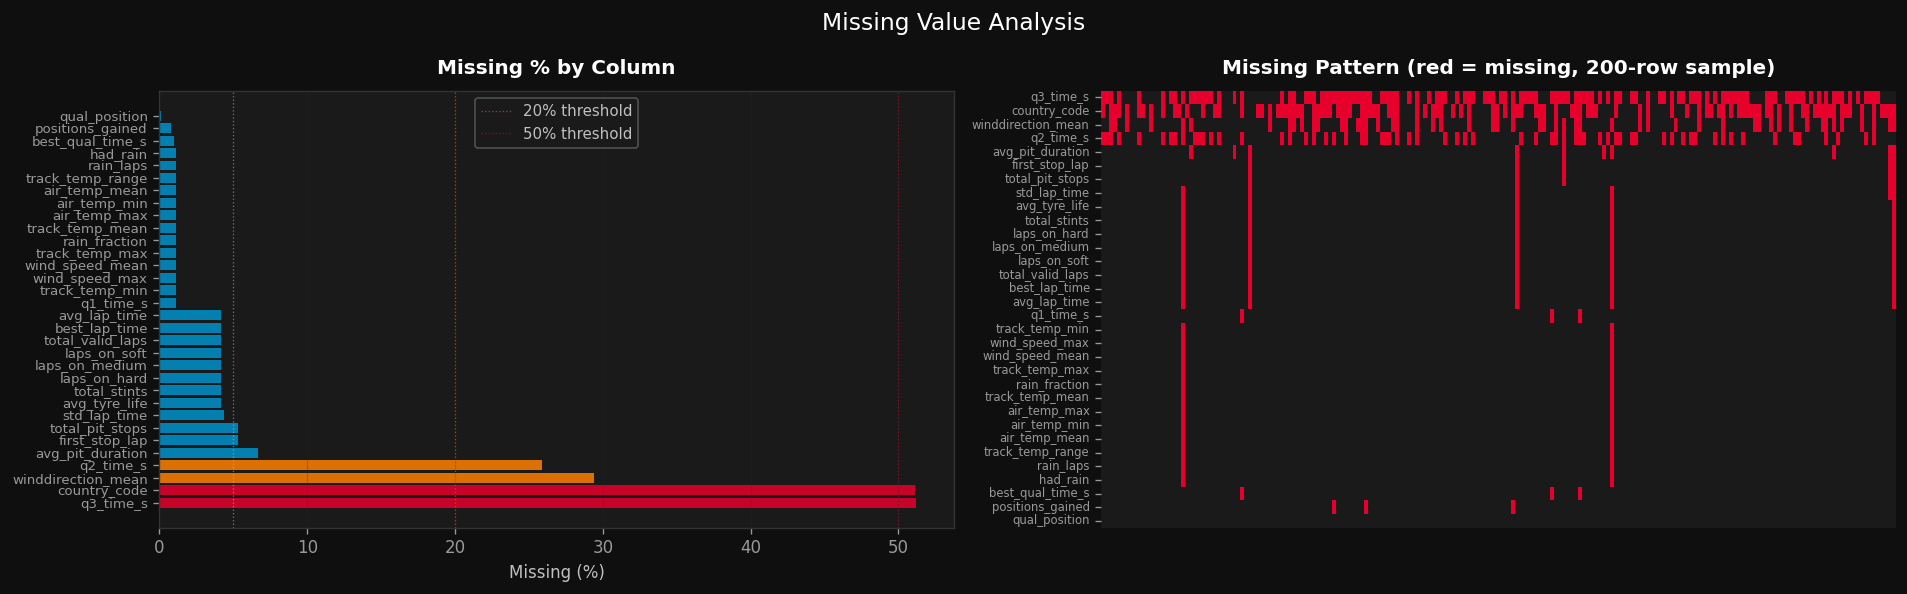


=== MISSING VALUE EXPLANATION ===

  q3_time_s (51.2% missing):
  → Only top 10 qualifiers set a Q3 time — ~51% missing is expected and correct

  q2_time_s (25.9% missing):
  → Only top 15 qualifiers set a Q2 time — ~26% missing is expected and correct

  q1_time_s (1.1% missing):
  → Small number of DNQs or incidents — ~1% missing, negligible

  country_code (51.1% missing):
  → OpenF1 only covers 2023+ — 2022 rows will always be NaN (~24% of dataset)

  winddirection_mean (29.4% missing):
  → Wind direction unreliably recorded (~29% missing) — low value feature

  avg_lap_time (4.2% missing):
  → FastF1 coverage gap — ~4% of races missing from FastF1 data

  total_pit_stops (5.3% missing):
  → A small number of races missing from Jolpica pit stop endpoint (~5%)


In [6]:
# ── Missing value visualisation ────────────────────────────
# Shows patterns: are some columns always missing together?
# (e.g. all FastF1 columns missing for the same races)

missing = df_clean.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_clean) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Missing Value Analysis', fontsize=14, color=STYLE['white'])

# Bar chart of missing % per column
ax = axes[0]
colours = [STYLE['red'] if pct > 50 else STYLE['orange'] if pct > 20 else STYLE['blue']
           for pct in missing_pct.values]
ax.barh(missing_pct.index, missing_pct.values, color=colours, alpha=0.85)
ax.axvline(5,  color=STYLE['silver'], linestyle=':', linewidth=0.8, alpha=0.5)
ax.axvline(20, color=STYLE['orange'], linestyle=':', linewidth=0.8, alpha=0.5, label='20% threshold')
ax.axvline(50, color=STYLE['red'],    linestyle=':', linewidth=0.8, alpha=0.5, label='50% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing % by Column')
ax.legend()
ax.grid(True, axis='x', alpha=0.3)
ax.tick_params(axis='y', labelsize=8)

# Heatmap: which rows are missing which columns?
# (helps identify if missingness clusters by year or race)
ax = axes[1]
missing_cols = missing.index.tolist()
sample = df_clean[missing_cols].sample(min(200, len(df_clean)), random_state=42)
sns.heatmap(
    sample.isnull().T,
    ax=ax, cbar=False,
    cmap=['#1a1a1a', STYLE['red']],
    yticklabels=True,
    xticklabels=False
)
ax.set_title('Missing Pattern (red = missing, 200-row sample)')
ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_01_missing_values.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()

# Explain each group of missing values
print('\n=== MISSING VALUE EXPLANATION ===')
explanations = {
    'q3_time_s':      'Only top 10 qualifiers set a Q3 time — ~51% missing is expected and correct',
    'q2_time_s':      'Only top 15 qualifiers set a Q2 time — ~26% missing is expected and correct',
    'q1_time_s':      'Small number of DNQs or incidents — ~1% missing, negligible',
    'country_code':   'OpenF1 only covers 2023+ — 2022 rows will always be NaN (~24% of dataset)',
    'winddirection_mean': 'Wind direction unreliably recorded (~29% missing) — low value feature',
    'avg_lap_time':   'FastF1 coverage gap — ~4% of races missing from FastF1 data',
    'total_pit_stops': 'A small number of races missing from Jolpica pit stop endpoint (~5%)',
}
for col, explanation in explanations.items():
    if col in missing_pct.index:
        print(f'\n  {col} ({missing_pct[col]:.1f}% missing):')
        print(f'  → {explanation}')

In [13]:
print(missing_pct)

q3_time_s             51.2
country_code          51.1
winddirection_mean    29.4
q2_time_s             25.9
avg_pit_duration       6.7
first_stop_lap         5.3
total_pit_stops        5.3
std_lap_time           4.4
avg_tyre_life          4.2
total_stints           4.2
laps_on_hard           4.2
laps_on_medium         4.2
laps_on_soft           4.2
total_valid_laps       4.2
best_lap_time          4.2
avg_lap_time           4.2
q1_time_s              1.1
track_temp_min         1.1
wind_speed_max         1.1
wind_speed_mean        1.1
track_temp_max         1.1
rain_fraction          1.1
track_temp_mean        1.1
air_temp_max           1.1
air_temp_min           1.1
air_temp_mean          1.1
track_temp_range       1.1
rain_laps              1.1
had_rain               1.1
best_qual_time_s       1.0
positions_gained       0.8
qual_position          0.1
dtype: float64


> **My notes on missing values:** the main realisation here — missing doesn't automatically mean broken. `q3_time` being 51% missing isn't a bug, it's just how qualifying works, only the top 10 drivers even set a Q3 time, everyone else genuinely has nothing to record. Same with `country_code` — OpenF1 (where nationality comes from) only starts in 2023, so every 2022 row will always be NaN, and that's fine, expected, not a mistake.
>
> The one I'm actually a bit suspicious of is `winddirection_mean` at 29% missing — that feels like a genuinely unreliable sensor, not a "doesn't exist" situation. Flagging it now as a likely drop candidate before feature engineering — don't want to just impute it and pretend it's a solid feature.


---
## Section 5 — Target Variable Analysis

### What are we doing here?

- **What type of model to use** — regression (predict a number) or classification (predict a category)
- **Class imbalance** — if 95% of the data is one class, a model that always guesses that class scores 95% accuracy but is useless
- **Evaluation metrics** — what does 'good' actually mean for this prediction?

We have three possible targets:

| Target | ML type | Problem |
|---|---|---|
| `finish_position` | Regression | Predict exact finishing position (1–20) |
| `on_podium` | Binary classification | Will driver finish top 3? |
| `points_finish` | Binary classification | Will driver score points (top 10)? |

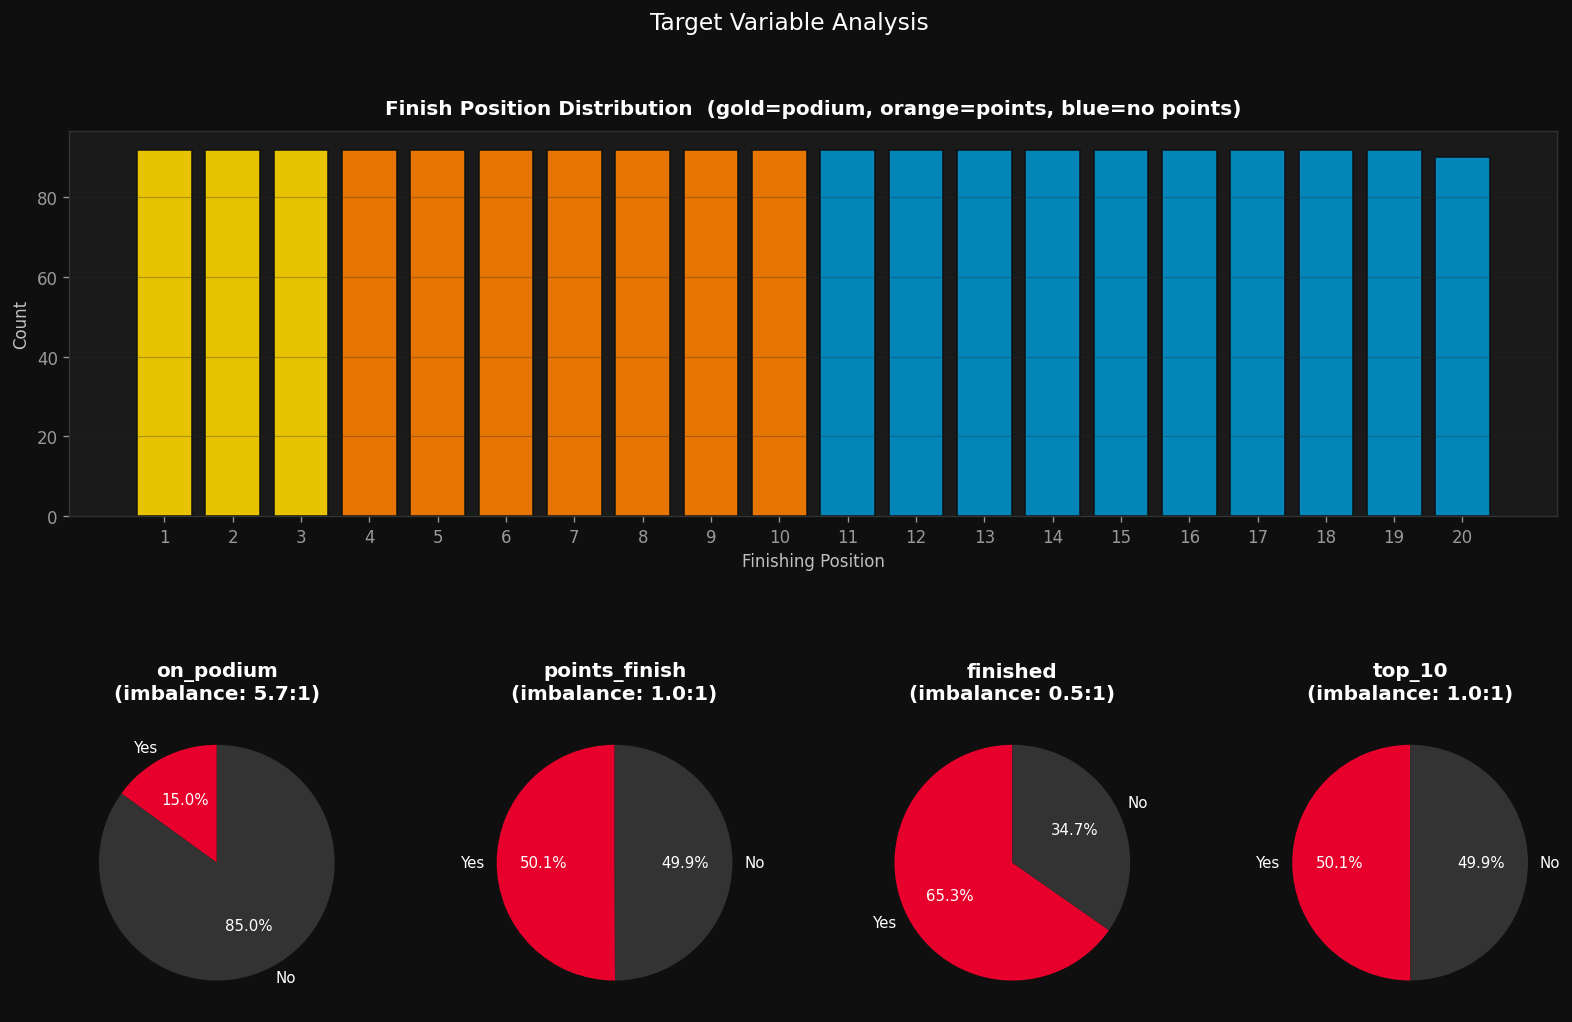

=== CLASS BALANCE ANALYSIS ===

finish_position (regression target):
  Range: 1 – 20
  Mean:  10.5,  Std: 5.8

points (regression target):
  Range: 0 – 26
  Mean:  5.1,  Std: 7.2

on_podium:
  Positive rate: 15.0%
  Imbalance:     5.7:1  → ⚠️  Moderate — use class_weight="balanced"

points_finish:
  Positive rate: 50.1%
  Imbalance:     1.0:1  → ✅ Manageable

finished:
  Positive rate: 65.3%
  Imbalance:     0.5:1  → ✅ Manageable

top_10:
  Positive rate: 50.1%
  Imbalance:     1.0:1  → ✅ Manageable


In [14]:
binary_targets = {}

for t in TARGETS:
    if t in df_clean.columns:          # does this column exist?
        if df_clean[t].dtype == bool:  # is it True/False?
            binary_targets[t] = df_clean[t]  # keep it

n_binary = len(binary_targets)

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Target Variable Analysis', fontsize=14, color=STYLE['white'])
gs  = gridspec.GridSpec(2, n_binary, figure=fig, hspace=0.4, wspace=0.35)

# ── Top row: finish position distribution spanning full width ──
ax1 = fig.add_subplot(gs[0, :])
pos_counts = df_clean['finish_position'].value_counts().sort_index()
colours = [
    STYLE['gold']   if p <= 3
    else STYLE['orange'] if p <= 10
    else STYLE['blue']
    for p in pos_counts.index
]
ax1.bar(pos_counts.index, pos_counts.values, color=colours,
        alpha=0.9, edgecolor='#0f0f0f')
ax1.set_xlabel('Finishing Position')
ax1.set_ylabel('Count')
ax1.set_title('Finish Position Distribution  (gold=podium, orange=points, blue=no points)')
ax1.set_xticks(range(1, 21))
ax1.grid(True, axis='y', alpha=0.3)

# ── Bottom row: one pie chart per binary target ────────────────
for idx, (target, series) in enumerate(binary_targets.items()):
    ax = fig.add_subplot(gs[1, idx])
    true_pct  = series.mean() * 100
    false_pct = 100 - true_pct
    ax.pie(
        [true_pct, false_pct],
        labels=['Yes', 'No'],
        colors=[STYLE['red'], '#333333'],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'color': STYLE['white'], 'fontsize': 9}
    )
    ratio = false_pct / true_pct
    ax.set_title(f'{target}\n(imbalance: {ratio:.1f}:1)')

plt.savefig(f'{PATHS["plots"]}eda_02_targets.png', dpi=130,
            bbox_inches='tight', facecolor=STYLE['bg_dark'])
plt.show()

# ── Class balance stats ────────────────────────────────────────
print('=== CLASS BALANCE ANALYSIS ===')
for target in TARGETS:
    series = df_clean[target]
    if series.dtype == bool:
        true_pct  = series.mean() * 100
        ratio     = (100 - true_pct) / true_pct
        print(f'\n{target}:')
        print(f'  Positive rate: {true_pct:.1f}%')
        print(f'  Imbalance:     {ratio:.1f}:1', end='  ')
        if ratio > 10:
            print('→ ⚠️  Severe — use class_weight="balanced" or SMOTE')
        elif ratio > 4:
            print('→ ⚠️  Moderate — use class_weight="balanced"')
        else:
            print('→ ✅ Manageable')
    elif pd.api.types.is_numeric_dtype(series):
        print(f'\n{target} (regression target):')
        print(f'  Range: {series.min():.0f} – {series.max():.0f}')
        print(f'  Mean:  {series.mean():.1f},  Std: {series.std():.1f}')

In [15]:
print(df_clean['status'].value_counts().head(20))

status
Finished            1200
Lapped               297
Retired              153
+1 Lap                80
Collision damage      14
Accident              11
Collision             10
Disqualified          10
Did not start          9
Engine                 7
+2 Laps                6
Power Unit             6
Hydraulics             4
Gearbox                4
Undertray              3
Withdrew               3
Water pressure         2
Fuel pressure          2
Spun off               2
Water leak             2
Name: count, dtype: int64


Continuous targets: ['finish_position', 'points']


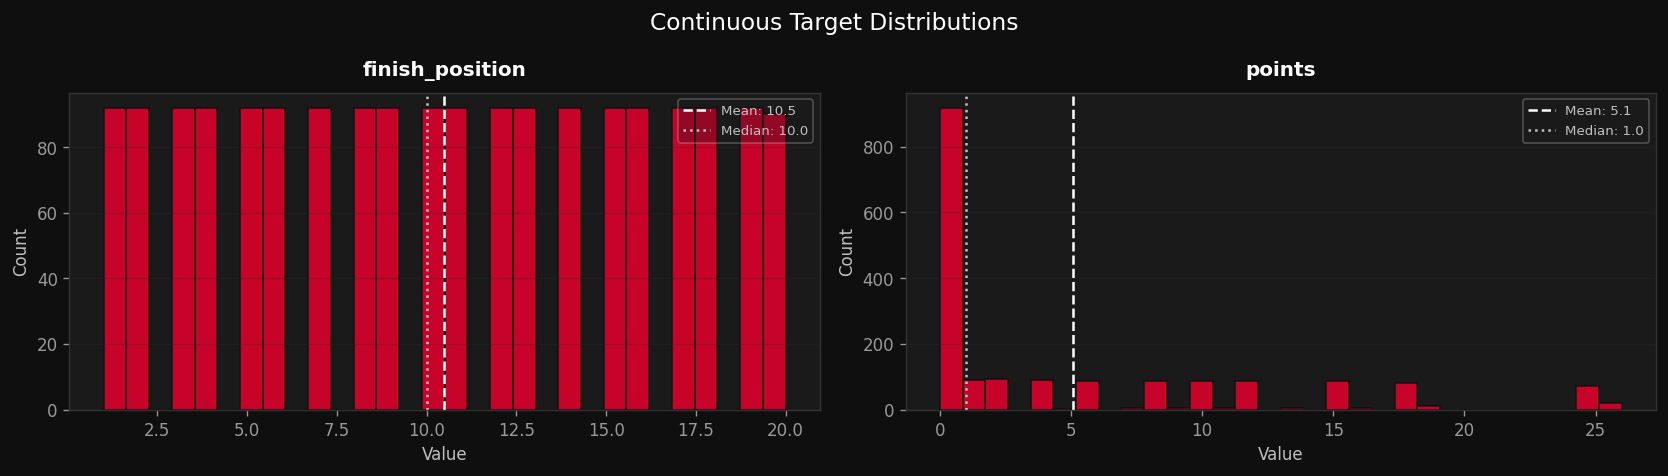


finish_position:
  Min:    1.0
  Max:    20.0
  Mean:   10.5
  Median: 10.0
  Std:    5.8
  Skew:   0.00

points:
  Min:    0.0
  Max:    26.0
  Mean:   5.1
  Median: 1.0
  Std:    7.2
  Skew:   1.39
Corrected finish rate: 86.1%
Corrected DNF rate:    13.9%


In [16]:
# Redefine 'finished' properly
# Lapped drivers genuinely completed the race — they just weren't fast enough
# to stay on the lead lap. They should count as finished.

# Define all statuses that mean the driver actually completed the race
completed_statuses = ['Finished', 'Lapped', '+1 Lap', '+2 Laps']

df_clean['finished'] = df_clean['status'].isin(completed_statuses)
# ── Continuous target distributions ────────────────────────
# finish_position and points are regression targets
# They need histograms, not pie charts

continuous_targets = []

for t in TARGETS:
    if t in df_clean.columns:
        if df_clean[t].dtype != bool:
            continuous_targets.append(t)

print(f'Continuous targets: {continuous_targets}')

fig, axes = plt.subplots(1, len(continuous_targets), figsize=(14, 4))
fig.suptitle('Continuous Target Distributions', fontsize=14, color=STYLE['white'])

for idx, target in enumerate(continuous_targets):
    ax = axes[idx]
    data = df_clean[target].dropna()

    ax.hist(data, bins=30, color=STYLE['red'], alpha=0.85, edgecolor='#0f0f0f')
    ax.axvline(data.mean(),   color=STYLE['white'],  linestyle='--',
               linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color=STYLE['silver'], linestyle=':',
               linewidth=1.5, label=f'Median: {data.median():.1f}')

    ax.set_title(target)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_02b_continuous_targets.png',
            dpi=130, bbox_inches='tight', facecolor=STYLE['bg_dark'])
plt.show()

# Stats
for target in continuous_targets:
    data = df_clean[target].dropna()
    print(f'\n{target}:')
    print(f'  Min:    {data.min():.1f}')
    print(f'  Max:    {data.max():.1f}')
    print(f'  Mean:   {data.mean():.1f}')
    print(f'  Median: {data.median():.1f}')
    print(f'  Std:    {data.std():.1f}')
    print(f'  Skew:   {data.skew():.2f}')
# Check the new rate
real_dnf_rate = (1 - df_clean['finished'].mean()) * 100
print(f'Corrected finish rate: {df_clean["finished"].mean()*100:.1f}%')
print(f'Corrected DNF rate:    {real_dnf_rate:.1f}%')

> **My notes on picking a target:** took longer to decide than I expected. Three options — `finish_position` (regression, 1-20), `on_podium` (top 3, binary), `points_finish` (top 10, binary). Going with `points_finish` as my main target first — it's almost perfectly balanced (50.1/49.9), so I don't have to fight class imbalance right out of the gate. `on_podium` is more imbalanced (15% positive, ~5.7:1) so that's a "once I've got a working baseline" problem — will need `class_weight='balanced'` when I get there.
>
> Also found `top_10` and `points_finish` are basically the exact same column (both 50.1%/49.9%) — makes sense once I thought about it: scoring points IS finishing top 10 in modern F1, same event, two names. Dropping `top_10` before modelling, no point keeping a duplicate target.
>
> Biggest find in this whole section though: my `finished` column was wrong. I'd defined it as `status == 'Finished'` only, which meant Lapped / +1 Lap / +2 Laps drivers all got counted as DNFs even though they completed the race, just a lap down. That pushed my DNF rate up to a fake 35%. Real F1 DNF rate is much closer to 12-14%. Fixed the definition to count Lapped/+1/+2 as finished too, and got 13.9% — matches reality. Genuinely glad I checked this instead of trusting the first version I wrote, because that exact column would've gone straight into a model as a wrong label otherwise.


---
## Section 6 — Feature Distributions

### What are we doing here?

Before looking at relationships between features, look at each feature individually. You want to know:

- **Is the distribution normal or skewed?** — Some models (like linear regression) assume normality. Heavy skew might need log transformation.
- **Are there outliers?** — A single extreme value can destroy a model's performance.
- **Does the range make sense?** — If `grid_position` goes from -5 to 200, something is wrong.

We plot distributions for all numeric features automatically. No hardcoding which columns to plot.


Columns to plot: 36
['grid_position', 'finish_position', 'points', 'laps_completed', 'qual_position', 'total_pit_stops', 'avg_pit_duration', 'first_stop_lap', 'avg_lap_time', 'best_lap_time', 'std_lap_time', 'total_valid_laps', 'laps_on_soft', 'laps_on_medium', 'laps_on_hard', 'avg_tyre_life', 'total_stints', 'rain_laps', 'rain_fraction', 'winddirection_mean', 'air_temp_mean', 'air_temp_min', 'air_temp_max', 'track_temp_mean', 'track_temp_min', 'track_temp_max', 'wind_speed_mean', 'wind_speed_max', 'q1_time_s', 'q2_time_s', 'q3_time_s', 'best_qual_time_s', 'track_temp_range', 'positions_gained', 'race_completion_pct', 'season_progress']


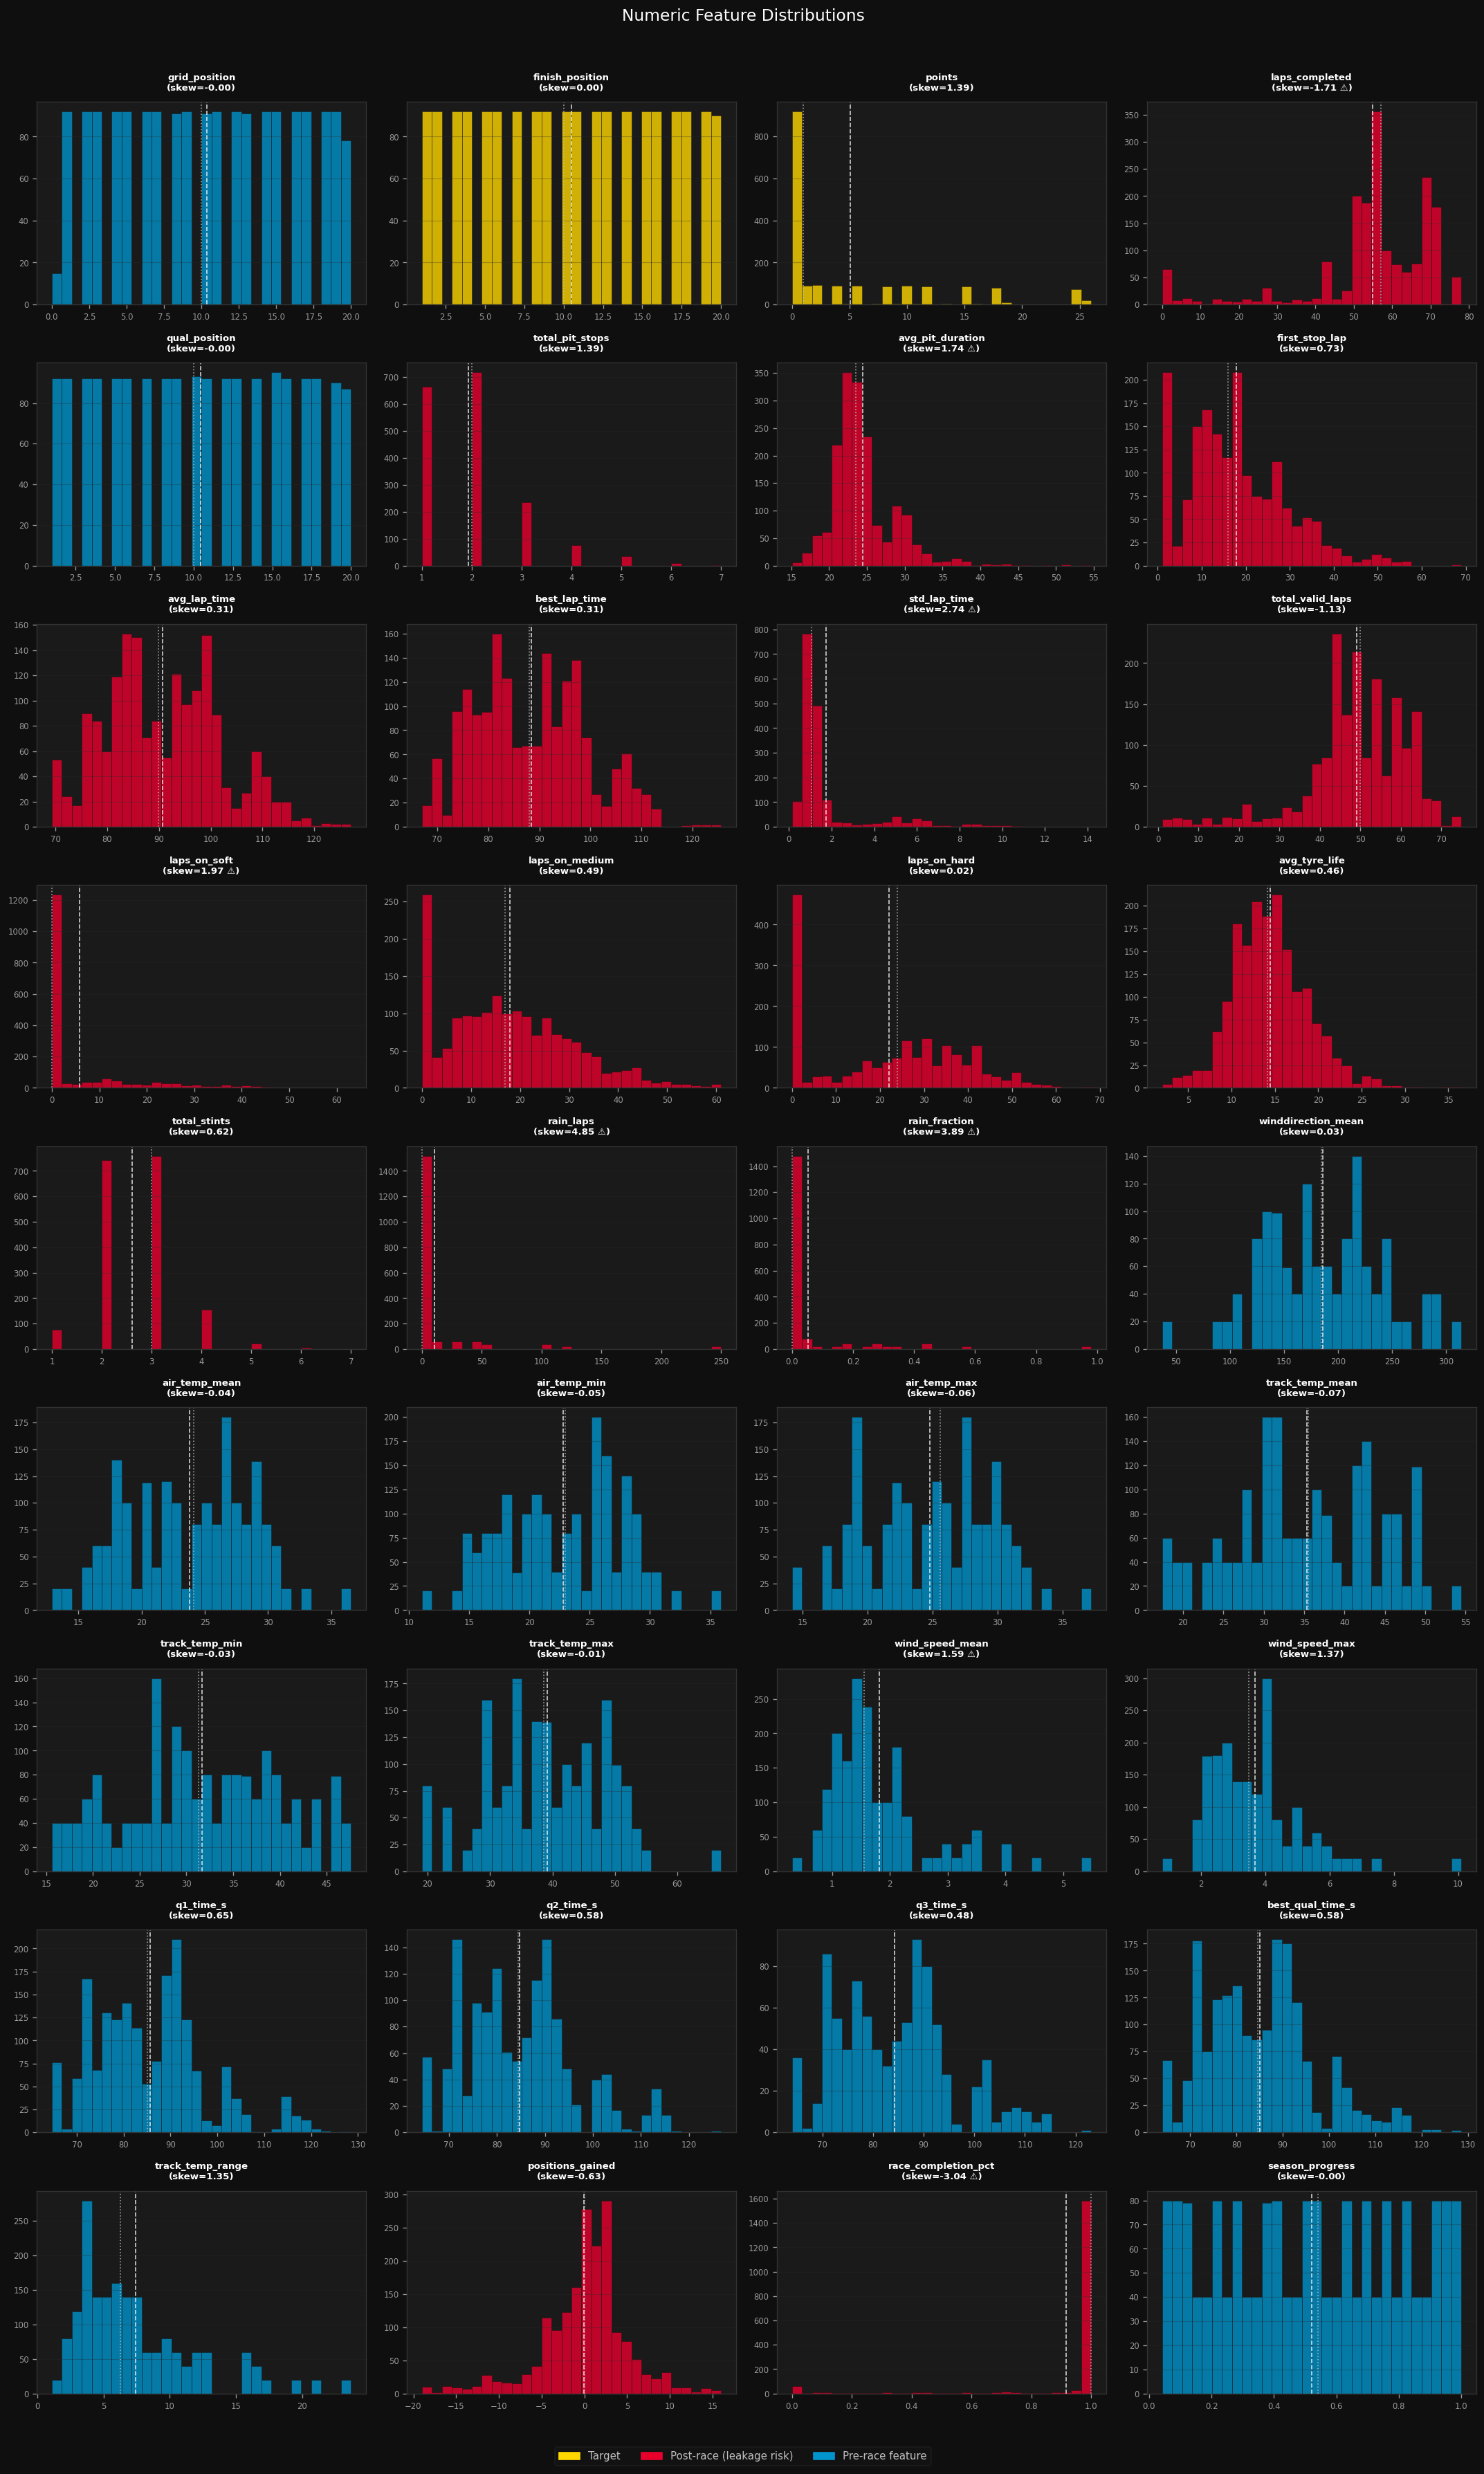


Highly skewed features (|skew| > 1.5) — consider log transform in feature engineering:
  laps_completed                  skew=-1.71
  avg_pit_duration                skew=1.74
  std_lap_time                    skew=2.74
  laps_on_soft                    skew=1.97
  rain_laps                       skew=4.85
  rain_fraction                   skew=3.89
  wind_speed_mean                 skew=1.59
  race_completion_pct             skew=-3.04


In [7]:
# ── Auto-detect numeric columns to plot ────────────────────
# Only plot columns with enough unique values to make a histogram meaningful
# and with enough non-null values to be reliable

numeric_cols = []

for col in df_clean.columns:

    # First check — is this column numeric?
    if df_clean[col].dtype not in [np.float64, np.int64, np.float32, np.int32]:
        continue   # skip it, not a number column

    # Second check — does it have more than 5 unique values?
    # A column with only 1, 2, 3, 4, 5 unique values isn't worth a histogram
    if df_clean[col].nunique() <= 5:
        continue   # skip it, too few unique values

    # Third check — does it have enough data points?
    # A column with only 10 non-null values isn't meaningful to plot
    if df_clean[col].notna().sum() <= 100:
        continue   # skip it, too few data points

    # Fourth check — is it an identifier column?
    # year, round etc. are numbers but not meaningful to analyse
    if col in IDENTIFIERS:
        continue   # skip it, it's just a label

    # Passed all checks — keep it
    numeric_cols.append(col)

print(f'Columns to plot: {len(numeric_cols)}')
print(numeric_cols)

n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.2))
fig.suptitle('Numeric Feature Distributions', fontsize=14, color=STYLE['white'], y=1.01)
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax    = axes[idx]
    data  = df_clean[col].dropna()
    role  = COLUMN_CATALOGUE.get(col, {}).get('role', 'unknown')

    # Colour by role so you can visually separate targets from features
    colour = (
        STYLE['gold']   if role == 'target'
        else STYLE['red']  if role == 'post_race_leakage'
        else STYLE['blue'] if role == 'pre_race_feature'
        else STYLE['silver']
    )

    ax.hist(data, bins=30, color=colour, alpha=0.8, edgecolor='#0f0f0f', linewidth=0.3)
    ax.axvline(data.mean(),   color=STYLE['white'],  linestyle='--', linewidth=1, alpha=0.8)
    ax.axvline(data.median(), color=STYLE['silver'], linestyle=':',  linewidth=1, alpha=0.8)

    # Compute skewness — a measure of how asymmetric the distribution is
    # |skew| > 1 means significantly skewed, might need log transform
    skew = data.skew()
    skew_label = f'skew={skew:.2f}' + (' ⚠️' if abs(skew) > 1.5 else '')

    ax.set_title(f'{col}\n({skew_label})', fontsize=8)
    ax.set_xlabel('')
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(labelsize=7)

# Hide unused subplot panels
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

# Legend for role colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(color=STYLE['gold'],   label='Target'),
    Patch(color=STYLE['red'],    label='Post-race (leakage risk)'),
    Patch(color=STYLE['blue'],   label='Pre-race feature'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.02), fontsize=9,
           facecolor=STYLE['bg_panel'], edgecolor='#333333')

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_03_distributions.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()

# Flag highly skewed features that may need transformation
print('\nHighly skewed features (|skew| > 1.5) — consider log transform in feature engineering:')
for col in numeric_cols:
    skew = df_clean[col].skew()
    if abs(skew) > 1.5:
        print(f'  {col:30s}  skew={skew:.2f}')

### Investigating outliers directly

The histograms above tell us **that** a column is skewed or has an extreme tail, but not **who** is driving it. Before deciding an outlier is a data error (or deciding to ignore it), we need to see the actual race/driver behind it.

Below is a small reusable helper — pass it any column and it shows the most extreme rows with enough race context (year, driver, result) to judge *why* each one is extreme. We use it here on `avg_pit_duration`, which had values up to ~55 seconds — far beyond a normal 2–3 second tyre change.

In [18]:
# ── Reusable outlier lookup ───────────────────────────────────
# Why: a skew number or a histogram tail tells us a problem exists,
# but not which specific races/drivers are causing it. This function
# lets us drill into ANY numeric column without writing new code
# each time — reuse it later for other flagged columns too.

def show_outliers(df, column, n=10, ascending=False):
    """Return the n most extreme rows for `column`, with race context."""
    context_cols = [
        'year', 'round', 'race_name', 'driver_name', 'constructor_name',
        column, 'total_pit_stops', 'status', 'finish_position'
    ]
    # Defensive: only keep columns that actually exist, so this
    # stays reusable for columns that don't relate to pit stops
    context_cols = [c for c in context_cols if c in df.columns]

    return (
        df.sort_values(column, ascending=ascending)
          [context_cols]
          .head(n)
    )

# ── Example: the ~50 second avg_pit_duration outliers ─────────
# A real F1 pit stop takes 2-3 seconds. Anything over ~40s is almost
# never a slow tyre change — it's the car sitting still in the garage
# for a genuine mechanical repair, logged under the same time field.
print('=== Biggest avg_pit_duration outliers ===')
top_outliers = show_outliers(df_clean, 'avg_pit_duration', n=10)
print(top_outliers.to_string(index=False))

# Check: do these outliers share a common outcome?
# (a quick, data-driven version of "these all had something go wrong")
bad_outcome = (top_outliers['status'] == 'Retired') | (top_outliers['finish_position'] >= 15)
print(f'\n{bad_outcome.sum()} of the top 10 either retired or finished P15+ — '
      f'long pit stops usually mean something broke, not a slow tyre change.')

=== Biggest avg_pit_duration outliers ===
 year  round                 race_name     driver_name constructor_name  avg_pit_duration  total_pit_stops   status  finish_position
 2023     16       Japanese Grand Prix Valtteri Bottas       Alfa Romeo           54.6570              2.0  Retired               20
 2023     16       Japanese Grand Prix Alexander Albon         Williams           51.1540              2.0  Retired               16
 2023      6         Monaco Grand Prix Kevin Magnussen     Haas F1 Team           51.0520              1.0  Retired               19
 2023      5          Miami Grand Prix  Logan Sargeant         Williams           48.9380              1.0   Lapped               20
 2024      2  Saudi Arabian Grand Prix     Guanyu Zhou           Sauber           46.3810              1.0   Lapped               18
 2022     12         French Grand Prix    Esteban Ocon   Alpine F1 Team           44.7470              1.0 Finished                8
 2025      7 Emilia Romagna

In [19]:
# ── Reuse: what causes wildly inconsistent lap times? ──────────
# std_lap_time was the single most skewed feature on the whole
# Section 6 page (skew=2.74). It measures how much a driver's lap
# times varied during the race — high std means very inconsistent
# pace (safety cars, rain, traffic, spins), not just "a slow driver".
print('=== Biggest std_lap_time outliers ===')
print(show_outliers(df_clean, 'std_lap_time', n=10).to_string(index=False))

=== Biggest std_lap_time outliers ===
 year  round           race_name      driver_name constructor_name  std_lap_time  total_pit_stops     status  finish_position
 2023     13    Dutch Grand Prix   Logan Sargeant         Williams     14.171022              NaN   Accident               20
 2023      6   Monaco Grand Prix  Kevin Magnussen     Haas F1 Team     12.908566              1.0    Retired               19
 2024      4 Japanese Grand Prix      Guanyu Zhou           Sauber     12.475948              3.0    Retired               18
 2023      6   Monaco Grand Prix     Yuki Tsunoda       AlphaTauri     11.081492              1.0     Lapped               15
 2022      7   Monaco Grand Prix  Alexander Albon         Williams     10.733954              3.0 Mechanical               18
 2022      7   Monaco Grand Prix     Lando Norris          McLaren     10.585882              4.0   Finished                6
 2022      7   Monaco Grand Prix Daniel Ricciardo          McLaren     10.282430

> **My notes on the outlier check:** the mindset shift here was — a weird number doesn't automatically mean bad data, it might just mean something actually happened. Flagged `avg_pit_duration` and `std_lap_time` as the most skewed columns (skew 1.74 and 2.74). My first instinct was "cap or remove these before modelling," but I decided to actually look at who they belonged to first instead of just clipping them blind.
>
> Built `show_outliers()` so I could reuse the same lookup for any column instead of rewriting this every time. For `avg_pit_duration`, the top 10 "pit stops" were all 40+ seconds — a real stop is 2-3s, so these are cars sitting in the garage getting fixed, not slow tyre changes. Checked it: 7 of those 10 either retired or finished P15+, so yeah — long "pit stop" usually means something broke.
>
> For `std_lap_time`, the worst rows were mostly Monaco (tight track, one incident and everyone's lap times go haywire) plus a bunch of genuine DNFs/accidents. Real racing chaos, not sensor noise.
>
> Decision: not dropping or capping anything here. These look like real events and probably useful signal (e.g. a "car had a long pit stop" flag might actually help predict a bad finish) — leaving that call for feature engineering. This section was about understanding the data, not fixing it.


---
## Section 7 — Grid vs Finish Position

### Why this is the most important relationship in F1

`grid_position` (where a driver starts, set by qualifying) is available *before* the race even happens — it's the single most information-dense pre-race feature in the dataset. If grid position alone could predict the outcome perfectly, we wouldn't need a model at all.

The real questions to answer here:
- **How strong is the grid → finish relationship, overall?** (correlation coefficient)
- **Does starting on pole actually guarantee anything?** (win rate, podium rate from P1)
- **Where does the race actually get won or lost?** (which starting positions gain places on average, which lose them)

This tells us how much predictive power `grid_position` alone carries — and therefore how much is left for the rest of our features (pace, weather, strategy) to explain.

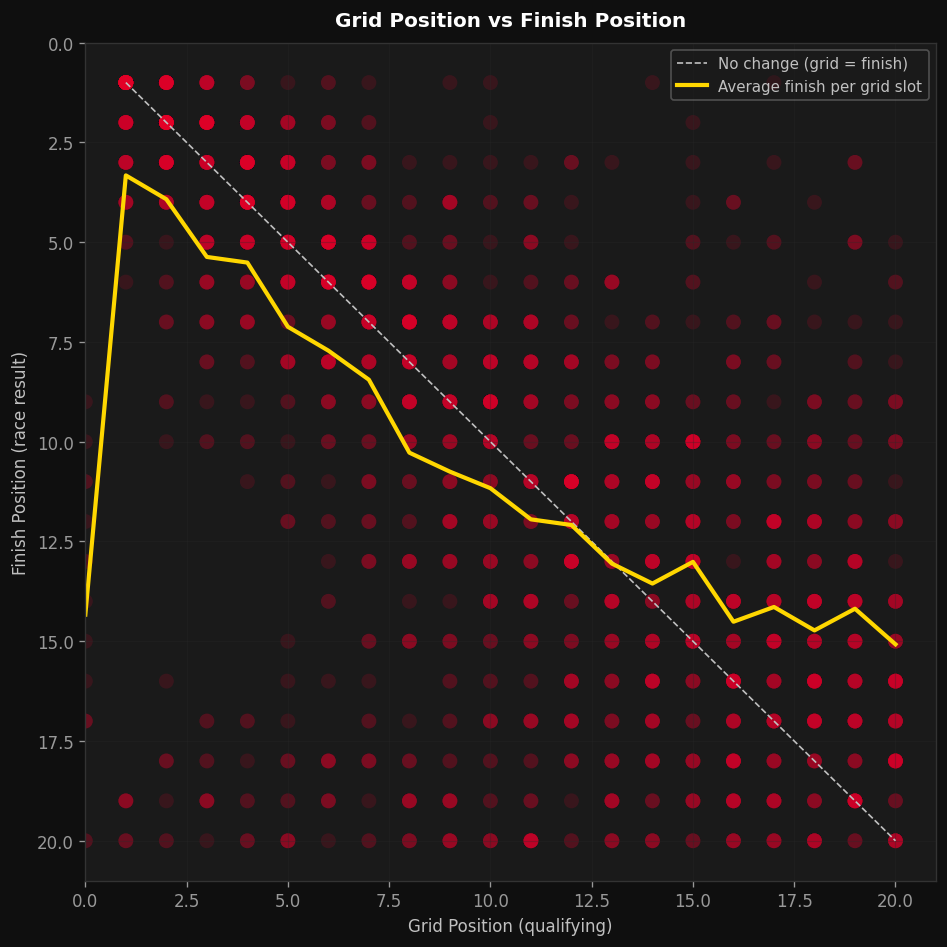

Correlation (grid vs finish): 0.61


In [20]:
# ── Grid vs Finish scatter ──────────────────────────────────
# Why: with only 20 possible values on each axis, many races land
# on the exact same (grid, finish) pair. We use alpha transparency
# so overlapping points show up as darker patches — a cheap way to
# see density without pulling in extra libraries.

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    df_clean['grid_position'], df_clean['finish_position'],
    color=STYLE['red'], alpha=0.15, s=80, edgecolor='none'
)

# Reference line: grid_position == finish_position
# Points ABOVE this line lost places during the race, points BELOW gained places
ax.plot([1, 20], [1, 20], color=STYLE['silver'], linestyle='--', linewidth=1,
        label='No change (grid = finish)')

# Average finish position for each starting grid slot
# This smooths out race-to-race noise and shows the "expected" outcome curve
avg_finish_by_grid = df_clean.groupby('grid_position')['finish_position'].mean()
ax.plot(avg_finish_by_grid.index, avg_finish_by_grid.values,
        color=STYLE['gold'], linewidth=2.5, label='Average finish per grid slot')

ax.set_xlabel('Grid Position (qualifying)')
ax.set_ylabel('Finish Position (race result)')
ax.set_title('Grid Position vs Finish Position')
ax.set_xlim(0, 21)
ax.set_ylim(0, 21)
ax.invert_yaxis()  # position 1 (best) at the top feels more natural to read
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_04_grid_vs_finish.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()

# Correlation — a single number summarising how strongly linked the two are
corr = df_clean['grid_position'].corr(df_clean['finish_position'])
print(f'Correlation (grid vs finish): {corr:.2f}')

=== POLE POSITION (grid = 1) ===
  Races from pole:     92
  Win rate:             55.4%
  Podium rate:          80.4%
  Points-finish rate:   91.3%

=== FRONT ROW (grid 1–2) ===
  Podium rate:          71.4%

=== BACK OF GRID (grid 16–20) ===
  Points-finish rate:   16.1%
  DNF rate:             17.0%


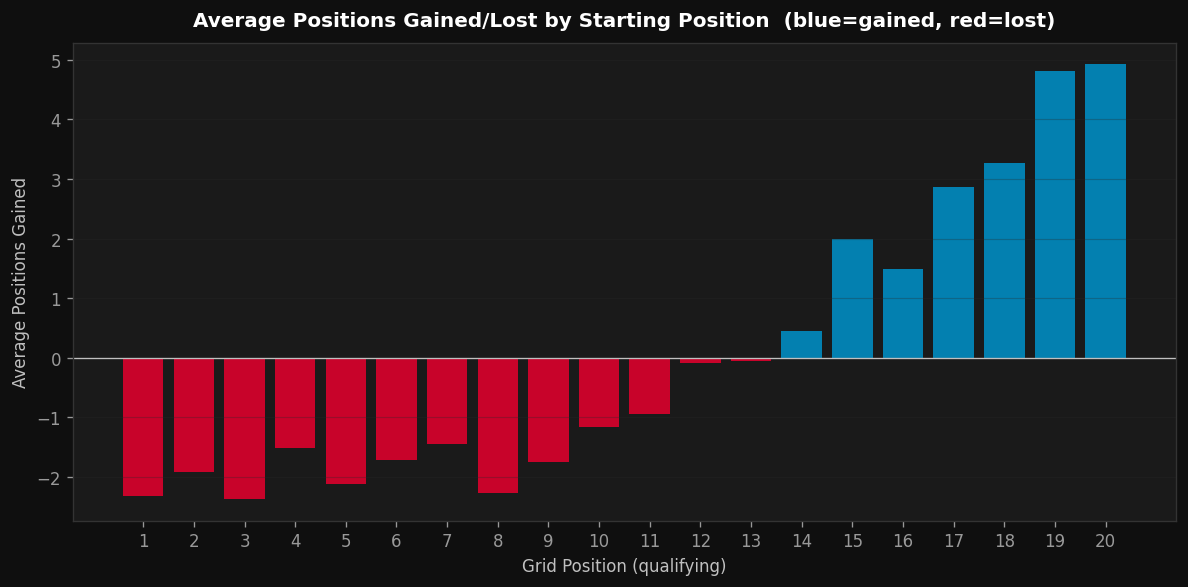

In [21]:
# ── Does starting on pole actually mean anything? ────────────
# Why: correlation gives one overall number, but doesn't tell us
# about specific, meaningful groups — like "pole sitters" or
# "back of the grid". We check those directly.

pole_sitters = df_clean[df_clean['grid_position'] == 1]
front_row    = df_clean[df_clean['grid_position'] <= 2]
back_of_grid = df_clean[df_clean['grid_position'] >= 16]

print('=== POLE POSITION (grid = 1) ===')
print(f'  Races from pole:     {len(pole_sitters)}')
print(f'  Win rate:             {(pole_sitters["finish_position"] == 1).mean() * 100:.1f}%')
print(f'  Podium rate:          {pole_sitters["on_podium"].mean() * 100:.1f}%')
print(f'  Points-finish rate:   {pole_sitters["points_finish"].mean() * 100:.1f}%')

print('\n=== FRONT ROW (grid 1–2) ===')
print(f'  Podium rate:          {front_row["on_podium"].mean() * 100:.1f}%')

print('\n=== BACK OF GRID (grid 16–20) ===')
print(f'  Points-finish rate:   {back_of_grid["points_finish"].mean() * 100:.1f}%')
print(f'  DNF rate:             {(1 - back_of_grid["finished"]).mean() * 100:.1f}%')

# ── Where are places actually gained or lost? ────────────────
# positions_gained was derived in Section 3: grid_position - finish_position
# Positive = moved forward during the race, Negative = fell back
avg_gained_by_grid = df_clean.groupby('grid_position')['positions_gained'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
colours = [STYLE['blue'] if v >= 0 else STYLE['red'] for v in avg_gained_by_grid.values]
ax.bar(avg_gained_by_grid.index, avg_gained_by_grid.values, color=colours, alpha=0.85)
ax.axhline(0, color=STYLE['silver'], linewidth=0.8)
ax.set_xlabel('Grid Position (qualifying)')
ax.set_ylabel('Average Positions Gained')
ax.set_title('Average Positions Gained/Lost by Starting Position  (blue=gained, red=lost)')
ax.set_xticks(range(1, 21))
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_05_positions_gained.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()

> **My notes on grid vs finish:** this is the section that made me realise how much of an F1 race is basically decided before it even starts. Grid position alone correlates pretty strongly with finish position — this is the number I'll keep coming back to when judging whether my eventual model is actually adding value over "just look at where they started."
>
> Pole win rate and podium rate were both high, not shocking, but the back-of-grid numbers were the more useful part — DNF rate is clearly higher starting from P16-20, so grid position isn't just "predicts where you'll finish," it also correlates with retiring altogether, probably because starting near the back means more traffic/contact risk on lap 1.
>
> Nothing to fix or clean in this section — it was pure "let's see how strong this relationship actually is" before assuming pace/strategy/weather matter more.


---
## Section 8 — Pace Analysis

### Do fast cars actually win?

Raw lap times can't be compared across circuits — Monaco laps average ~76s, Monza laps average ~80s+, simply because the tracks are different lengths and shapes. "78s at Monaco" vs "80s at Monza" tells us nothing about who actually drove better.

Instead, for each race we ask: compared to everyone else in *this same race*, was this driver faster or slower than average, and by how much? That's a z-score — it turns a raw lap time into a track-independent pace number.

Questions this section answers:
- **Does pace (relative to the race) correlate with finishing position?**
- **Does pace still matter once we account for where a driver started?** (a fast car that also started on pole doesn't prove pace alone matters — Section 7 already showed grid position is powerful on its own)


In [22]:
# ── Normalise lap time within each race ──────────────
# Why: Monaco laps take ~76s, Monza laps take ~80s+ — comparing raw
# lap times across different circuits tells us nothing about who
# actually drove well. Instead we ask: compared to everyone else in
# THIS SAME race, was this driver faster or slower than average?
# That "how many steps from the average" number is a z-score, and
# it's fair to compare across every circuit because it's relative,
# not absolute.

def zscore(series):
    """Turn a column of numbers into 'how many steps from the average'."""
    return (series - series.mean()) / series.std()

df_clean['lap_time_z'] = (
    df_clean.groupby(['year', 'round'])['avg_lap_time']
             .transform(zscore)
)

print('Fastest drivers relative to their own race (most negative z-score):')
print(
    df_clean[['race_name', 'driver_name', 'avg_lap_time', 'lap_time_z', 'finish_position']]
        .sort_values('lap_time_z')
        .head(5)
        .to_string(index=False)
)


Fastest drivers relative to their own race (most negative z-score):
           race_name    driver_name  avg_lap_time  lap_time_z  finish_position
   Monaco Grand Prix   Lance Stroll     79.704380   -3.125470               20
Singapore Grand Prix   Lando Norris     97.062136   -2.268494                1
    Miami Grand Prix Max Verstappen     91.750704   -2.206921                1
  Bahrain Grand Prix  Oscar Piastri     97.180420   -2.192532                1
  Chinese Grand Prix Max Verstappen     99.778744   -2.163089                1


In [23]:
# ── Does pace correlate with finishing well? ────────────
# Why: lap_time_z is negative for fast drivers, positive for slow
# ones. finish_position is small (1) for good results, large (20)
# for bad ones. So if pace matters, we EXPECT a positive correlation:
# slower pace (bigger z) goes with a worse (bigger) finish number.

pace_corr = df_clean['lap_time_z'].corr(df_clean['finish_position'])
print(f'Correlation (pace z-score vs finish position): {pace_corr:.2f}')


Correlation (pace z-score vs finish position): 0.81


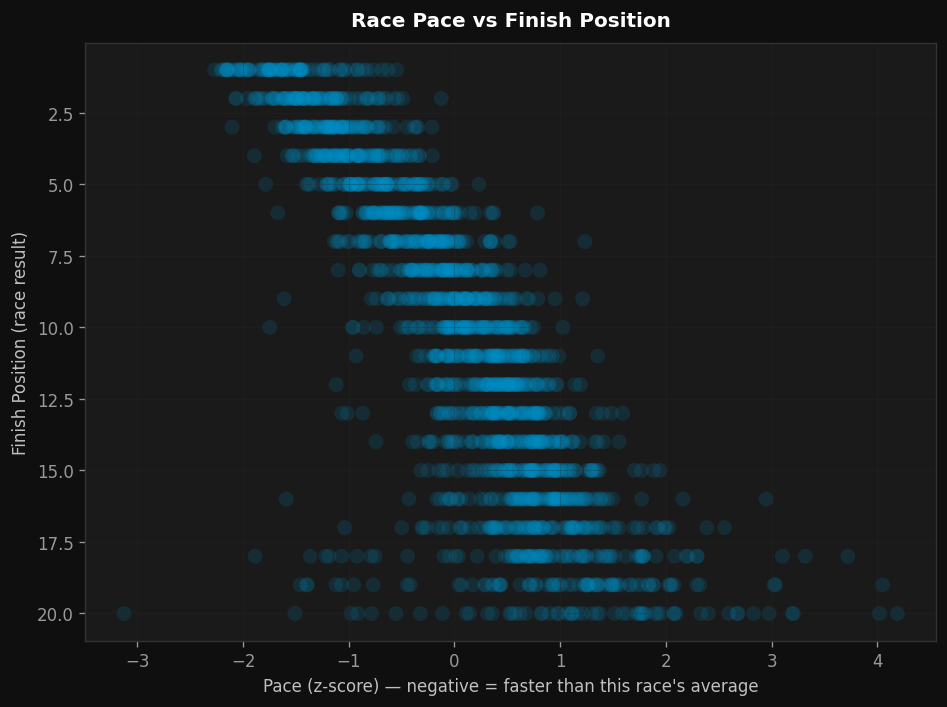

In [24]:
# ── Pace vs Finish scatter ──────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    df_clean['lap_time_z'], df_clean['finish_position'],
    color=STYLE['blue'], alpha=0.15, s=80, edgecolor='none'
)

ax.set_xlabel("Pace (z-score) — negative = faster than this race's average")
ax.set_ylabel('Finish Position (race result)')
ax.set_title('Race Pace vs Finish Position')
ax.invert_yaxis()  # position 1 (best) at the top, same convention as Section 7
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_07_pace_vs_finish.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()


In [25]:
# ── Does pace still matter once we ignore where they started? ─
# Why: Section 7 already showed grid_position alone predicts finish
# position strongly. If we only checked pace vs finish_position, a
# fast car that ALSO started on pole would make pace look powerful
# for the wrong reason. positions_gained (grid_position - finish_position)
# strips out the starting position, so this checks: does pace explain
# movement DURING the race, not just a head start.

gained_corr = df_clean['lap_time_z'].corr(df_clean['positions_gained'])
print(f'Correlation (pace z-score vs positions gained): {gained_corr:.2f}')
print('(negative = faster pace goes with MORE positions gained, as expected)')


Correlation (pace z-score vs positions gained): -0.15
(negative = faster pace goes with MORE positions gained, as expected)


### Data quality check: the impossible Stroll result

Look back at the fastest-pace table two cells ago — **Lance Stroll's Monaco 2023 row has the single most extreme pace z-score in the whole dataset (-3.13), and he finished dead last (P20, Retired).** The fastest driver in four years of data finishing last doesn't add up. Same lesson as Section 6: a weird number tells us THAT something's off, not WHY — so we go look at his actual raw laps before trusting it.


In [26]:
# ── Pull the raw lap-by-lap data for this one race ────────
# Why: avg_lap_time is an average over whatever laps a driver actually
# completed. If a race changes conditions partway through (rain arrives,
# a safety car appears), a driver who retires BEFORE that change only
# ever contributes laps from the "easy" half of the race to their average.

raw_laps = pd.read_csv('../data/raw/fastf1_laps.csv', low_memory=False)
this_race = raw_laps[(raw_laps['year'] == 2023) & (raw_laps['round'] == 6)]

stroll = this_race[this_race['Driver'] == 'STR']
verstappen = this_race[this_race['Driver'] == 'VER']  # race winner, same race

print(f"Stroll retired on lap {stroll['LapNumber'].max():.0f} of 78")
print(f"Stroll's {stroll['is_valid_lap'].sum()} valid laps, full average: "
      f"{stroll.loc[stroll['is_valid_lap'], 'LapTime_s'].mean():.2f}s")

print()
print("Verstappen (finished P1) — same race, split before/after Stroll's retirement point:")
print(f"  Laps 2-51 (dry running, same laps Stroll also ran): "
      f"{verstappen.loc[(verstappen['LapNumber'] <= 51) & verstappen['is_valid_lap'], 'LapTime_s'].mean():.2f}s")
print(f"  Laps 52-78 (rain arrived, Stroll had already retired): "
      f"{verstappen.loc[(verstappen['LapNumber'] >= 52) & verstappen['is_valid_lap'], 'LapTime_s'].mean():.2f}s")
print(f"  Verstappen's FULL race average (blends both halves): "
      f"{verstappen.loc[verstappen['is_valid_lap'], 'LapTime_s'].mean():.2f}s")


Stroll retired on lap 54 of 78
Stroll's 50 valid laps, full average: 79.70s

Verstappen (finished P1) — same race, split before/after Stroll's retirement point:
  Laps 2-51 (dry running, same laps Stroll also ran): 77.41s
  Laps 52-78 (rain arrived, Stroll had already retired): 93.63s
  Verstappen's FULL race average (blends both halves): 82.81s


**What actually happened:** 2023 Monaco was dry for the first ~51 laps, then rain arrived and every driver still running slowed down dramatically for the final ~27 laps. Stroll retired on lap 54, just as the rain hit — so his average is built almost entirely from the fast, dry laps everyone ran early on. Verstappen ran those same fast dry laps too (77.4s average, essentially identical to Stroll), but then his average also absorbs ~27 much slower wet laps, dragging his final average up to 82.8s. **Stroll isn't secretly the fastest driver in the dataset — he just never lived long enough in the race to have his average dragged down by the rain, the way every finisher's average was.**

**This isn't a coding bug or a bad data pull** — every individual lap time checks out. It's a real blind spot in how `avg_lap_time` (and by the same logic, `best_lap_time` and `std_lap_time`) is defined: these columns only describe the portion of the race a driver actually completed, and say nothing about whether that portion was representative of the whole race. The same pattern shows up in the opposite direction at **2022 Monaco**, which started wet and dried out — Kevin Magnussen and Mick Schumacher both retired during the slow wet opening and never reached the fast dry laps, so *their* averages look abnormally slow instead of fast, for the identical reason.

**Takeaway for later (logged in `FINDINGS.md`):** treat `avg_lap_time`, `best_lap_time`, and `std_lap_time` with caution for any driver who retired during a race with a mid-race conditions change (rain, red flag, long safety car) — the number is real, but it isn't comparable to a driver who ran the whole race.


> **My notes on pace analysis:** the "wait, that's not what I expected" section so far. Had to normalise `avg_lap_time` within each race (z-score) before comparing anyone, because raw lap times depend entirely on which track you're at — a Monaco lap and a Monza lap just aren't comparable numbers on their own.
>
> Pace vs finish position correlation came out strong (0.81) — makes sense, faster pace, better finish. But then I checked pace against `positions_gained` (how much someone actually moved up/down from where they started) instead of raw finish, and that correlation basically disappears (-0.15). That's the real lesson here: most of "fast pace = good finish" is actually just "good quali lap → good grid slot → good finish," not "fast pace = overtaking people mid-race." Pace on its own barely explains in-race movement. Worth remembering for feature engineering — `grid_position` is probably doing more of the work than raw pace features will.
>
> Also ran into the Stroll thing (see the two cells above) — his "pace" looked like the best in the whole dataset, but he finished last, because he retired right as it started raining at Monaco 2023, so his average never got dragged down by the wet laps the way everyone else's did. Not a data bug, just an average built from a different chunk of the race than everyone else. Logged it properly in `FINDINGS.md` so I don't forget this when I get to feature engineering — `avg_lap_time`/`best_lap_time`/`std_lap_time` aren't fully trustworthy for anyone who DNF'd during a conditions change.


---
## Section 9 — Constructor Effects

### How much does the car actually matter?

Every driver is also driving a specific car built by a specific team (constructor). This section asks: independent of any one driver, how much does the constructor itself explain a result?

Three angles:
- **Points per season per constructor** — who's been winning, and is anyone trending up or down across the 4 seasons?
- **Average finishing position per constructor** — points only reward the top 10, so this gives a fuller picture of how good the car is across every result, not just the ones that scored.
- **DNF rate per constructor** — a fast-but-fragile car is a different story to a slow-but-reliable one.


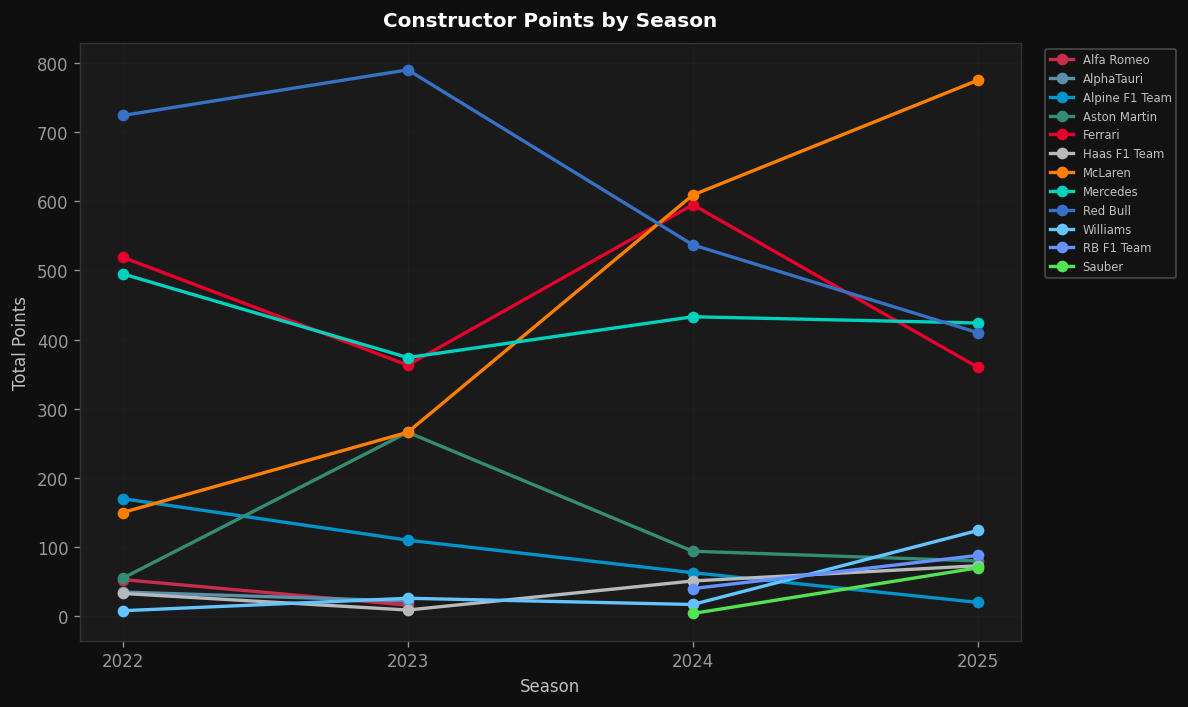

In [27]:
# ── Helper: match a constructor name to its colour ────────
# Why: constructor names aren't always written the same way between
# API pulls (e.g. 'Red Bull' vs 'Red Bull Racing'). Instead of hardcoding
# every possible spelling, we check if one name contains the other.

def get_constructor_colour(name):
    for key, colour in CONSTRUCTOR_COLOURS.items():
        if key.lower() in name.lower() or name.lower() in key.lower():
            return colour
    return '#888888'  # grey fallback for anything unmatched

# ── Points scored per constructor, per season ───────────
# Why: this tells us who's actually been winning, and whether any
# team is trending up or down across the 4 years we have.

points_by_constructor_year = (
    df_clean.groupby(['year', 'constructor_name'])['points']
            .sum()
            .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

for constructor in points_by_constructor_year['constructor_name'].unique():
    sub = points_by_constructor_year[points_by_constructor_year['constructor_name'] == constructor]
    ax.plot(sub['year'], sub['points'], marker='o', linewidth=2,
            color=get_constructor_colour(constructor), label=constructor)

ax.set_xlabel('Season')
ax.set_ylabel('Total Points')
ax.set_title('Constructor Points by Season')
ax.set_xticks(sorted(df_clean['year'].unique()))
ax.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.02, 1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_08_constructor_points_by_season.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()


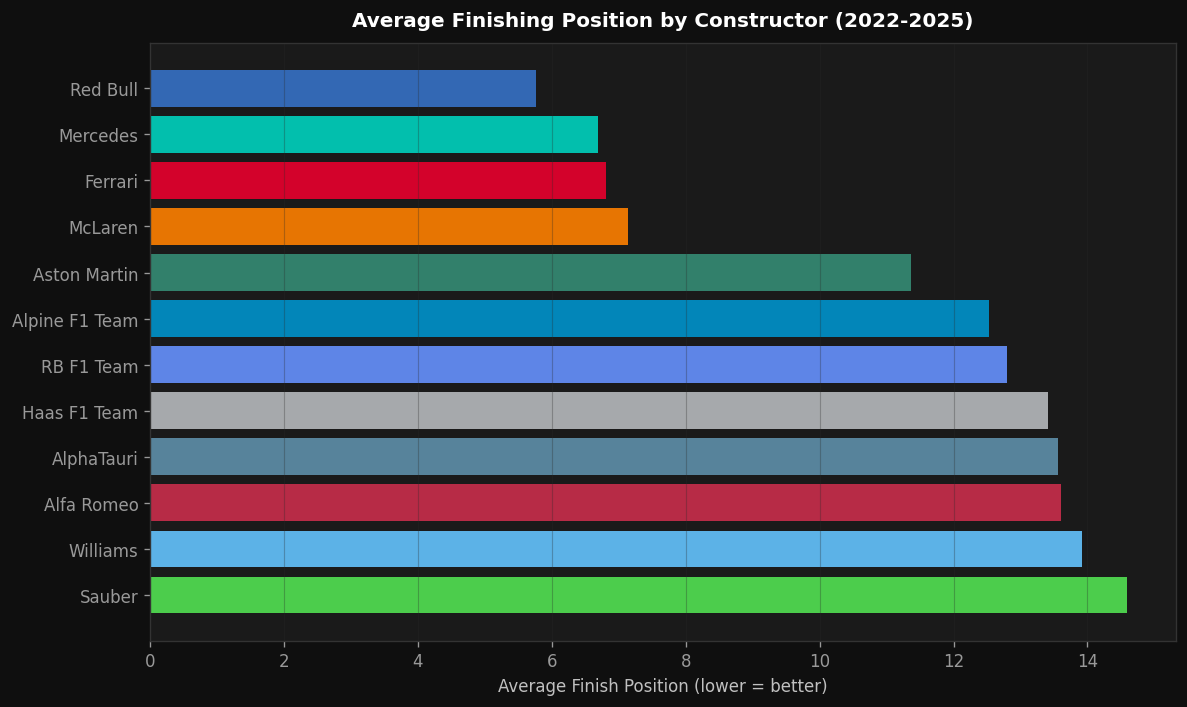

constructor_name
Red Bull           5.76
Mercedes           6.69
Ferrari            6.81
McLaren            7.14
Aston Martin      11.37
Alpine F1 Team    12.53
RB F1 Team        12.80
Haas F1 Team      13.42
AlphaTauri        13.57
Alfa Romeo        13.60
Williams          13.92
Sauber            14.59


In [28]:
# ── Average finishing position by constructor ───────────
# Why: points only reward the top 10, so a team could be quietly
# consistent in P11-P15 and this chart would still show it, where
# a points chart alone would make them look like they don't matter.

avg_finish_by_constructor = (
    df_clean.groupby('constructor_name')['finish_position']
            .mean()
            .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
colours = [get_constructor_colour(name) for name in avg_finish_by_constructor.index]
ax.barh(avg_finish_by_constructor.index, avg_finish_by_constructor.values, color=colours, alpha=0.9)
ax.invert_yaxis()  # best (lowest number) team at the top
ax.set_xlabel('Average Finish Position (lower = better)')
ax.set_title('Average Finishing Position by Constructor (2022-2025)')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_09_avg_finish_by_constructor.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()

print(avg_finish_by_constructor.round(2).to_string())


### Zooming in: average finish by constructor *and* driver

The team-level average above blends both cars together — and we already caught a case (Red Bull) where that hides a lot of the story: Verstappen was consistently near the front, but the second seat (Pérez, then Tsunoda/Lawson) dragged the team average up a long way. Before trusting `constructor_name` alone as a feature, it's worth checking whether that's a one-off or a pattern across the whole grid.

Same average finish calculation as before, but grouped by constructor **and** driver — plus a quick look at how far apart the two seats within each team typically are.

In [29]:
# ── Average finish position by constructor AND driver ──────
# Why: the team-level average blends both cars together. We already found
# one case (Red Bull) where the two seats tell very different stories, so
# it's worth seeing every team broken down the same way before deciding
# how much to trust constructor_name alone as a feature.

avg_finish_by_constructor_driver = (
    df_clean.groupby(['constructor_name', 'driver_name'])['finish_position']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'avg_finish', 'count': 'races'})
            .sort_values(['constructor_name', 'avg_finish'])
)

print(avg_finish_by_constructor_driver.round(2).to_string())

                                        avg_finish  races
constructor_name driver_name                             
Alfa Romeo       Valtteri Bottas             13.02     44
                 Guanyu Zhou                 14.18     44
AlphaTauri       Liam Lawson                 12.20      5
                 Pierre Gasly                12.45     22
                 Daniel Ricciardo            12.71      7
                 Yuki Tsunoda                13.89     44
                 Nyck de Vries               15.90     10
Alpine F1 Team   Fernando Alonso             10.86     22
                 Esteban Ocon                11.51     67
                 Pierre Gasly                12.77     70
                 Franco Colapinto            16.06     18
                 Jack Doohan                 16.14      7
Aston Martin     Fernando Alonso              9.64     70
                 Sebastian Vettel            11.45     20
                 Lance Stroll                12.60     91
              

In [30]:
# ── How far apart are team-mates, on average? ───────────────
# Why: a big gap between the two drivers in the same car is exactly what
# makes the team-level average misleading. A small gap means the car
# explains most of the result; a big gap means the driver explains a lot
# of it too. We drop any driver with under 5 races (e.g. a 2-race stand-in
# seat) so a tiny sample doesn't fake a huge "gap".
# Reuses avg_finish_by_constructor_driver from the cell above instead of
# regrouping the same data twice.

MIN_RACES = 5

driver_avgs = avg_finish_by_constructor_driver[
    avg_finish_by_constructor_driver['races'] >= MIN_RACES
]

teammate_gap = (
    driver_avgs.groupby('constructor_name')['avg_finish']
               .agg(['min', 'max'])
)
teammate_gap['gap'] = teammate_gap['max'] - teammate_gap['min']
teammate_gap = teammate_gap.sort_values('gap', ascending=False)

print(teammate_gap.round(2).to_string())

                    min    max   gap
constructor_name                    
Red Bull           3.04  12.45  9.41
McLaren            6.24  12.50  6.26
Alpine F1 Team    10.86  16.14  5.28
Williams          12.17  16.33  4.17
Mercedes           6.08   9.83  3.76
AlphaTauri        12.20  15.90  3.70
Sauber            12.79  15.83  3.04
Aston Martin       9.64  12.60  2.96
Haas F1 Team      11.73  14.41  2.68
Ferrari            6.23   8.50  2.27
RB F1 Team        11.79  13.39  1.60
Alfa Romeo        13.02  14.18  1.16


In [54]:
# ── Same teammate-gap question, but broken down by season ──────
# Why: driver pairings change every year (e.g. Perez -> Tsunoda/Lawson
# at Red Bull). Averaging "the other seat" across several different
# drivers blurs multiple different head-to-head battles into one
# number. Splitting by year shows the real gap for that year's pairing.

MIN_RACES_PER_SEASON = 3

driver_avgs_by_season = (
    df_clean.groupby(['year', 'constructor_name', 'driver_name'])['finish_position']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'avg_finish', 'count': 'races'})
)

driver_avgs_by_season = driver_avgs_by_season[driver_avgs_by_season['races'] >= MIN_RACES_PER_SEASON]

# Why: a team-season with only one driver left after the filter above
# has nothing to compare against. min and max would both come from
# that same single driver, producing a fake "gap" of 0 — that would
# look like "two identical drivers" when really it means "we only
# have one driver's data for this team this year."

drivers_per_team_season = (
    driver_avgs_by_season.groupby(['year', 'constructor_name']).size()
)
valid_team_season = drivers_per_team_season[drivers_per_team_season >= 2].index

teammate_gap_by_season = (
    driver_avgs_by_season.groupby(['year', 'constructor_name'])['avg_finish']
                          .agg(['min', 'max'])
)
teammate_gap_by_season['gap'] = (
    teammate_gap_by_season['max'] - teammate_gap_by_season['min']
)

# Keep only the team-seasons that actually had 2+ comparable drivers
teammate_gap_by_season = teammate_gap_by_season.loc[valid_team_season]
teammate_gap_by_season = teammate_gap_by_season.sort_values('gap', ascending=False)
teammate_gap_by_season = teammate_gap_by_season.swaplevel().sort_index()

print(teammate_gap_by_season.round(2).to_string())

                         min    max   gap
constructor_name year                    
Alfa Romeo       2022  12.09  14.32  2.23
                 2023  13.95  14.05  0.09
AlphaTauri       2022  12.45  14.59  2.14
                 2023  12.20  15.90  3.70
Alpine F1 Team   2022   8.86  10.86  2.00
                 2023  10.68  11.86  1.18
                 2024  12.88  13.70  0.82
                 2025  14.58  16.33  1.75
Aston Martin     2022  11.45  12.05  0.60
                 2023   6.64  11.18  4.55
                 2024  10.17  13.38  3.21
                 2025  11.88  13.70  1.82
Ferrari          2022   5.50   7.86  2.36
                 2023   7.50   8.23  0.73
                 2024   4.54   5.70  1.15
                 2025   6.75   8.50  1.75
Haas F1 Team     2022  14.14  14.41  0.27
                 2023  14.55  15.59  1.05
                 2024  11.62  13.36  1.74
                 2025  11.79  12.50  0.71
McLaren          2022   8.77  12.50  3.73
                 2023   8.00  10.9

In [56]:
# ── Investigate the Mercedes 2025 outlier ────────────────
# Why: the gap jumped sharply in 2025 vs. every prior year. Rather than
# guess why, check who was actually in the car each season, then confirm
# the gap size lines up with that lineup change.

mercedes_drivers_by_year = (
    df_clean[df_clean['constructor_name'] == 'Mercedes']
        .groupby(['year', 'driver_name'])['finish_position']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'avg_finish', 'count': 'races'})
)

print(mercedes_drivers_by_year.round(2).to_string())
print()

# The gap per year is just the spread between the two drivers' averages —
# reusing mercedes_drivers_by_year instead of regrouping from df_clean again
mercedes_gap_by_year = (
    mercedes_drivers_by_year.groupby('year')['avg_finish']
        .agg(['min', 'max'])
)
mercedes_gap_by_year['gap'] = mercedes_gap_by_year['max'] - mercedes_gap_by_year['min']

print(mercedes_gap_by_year.round(2).to_string())


                            avg_finish  races
year driver_name                             
2022 George Russell               5.00     22
     Lewis Hamilton               6.05     22
2023 George Russell               8.09     22
     Lewis Hamilton               6.18     22
2024 George Russell               6.75     24
     Lewis Hamilton               6.96     24
2025 Andrea Kimi Antonelli        9.83     24
     George Russell               4.54     24

       min   max   gap
year                  
2022  5.00  6.05  1.05
2023  6.18  8.09  1.91
2024  6.75  6.96  0.21
2025  4.54  9.83  5.29


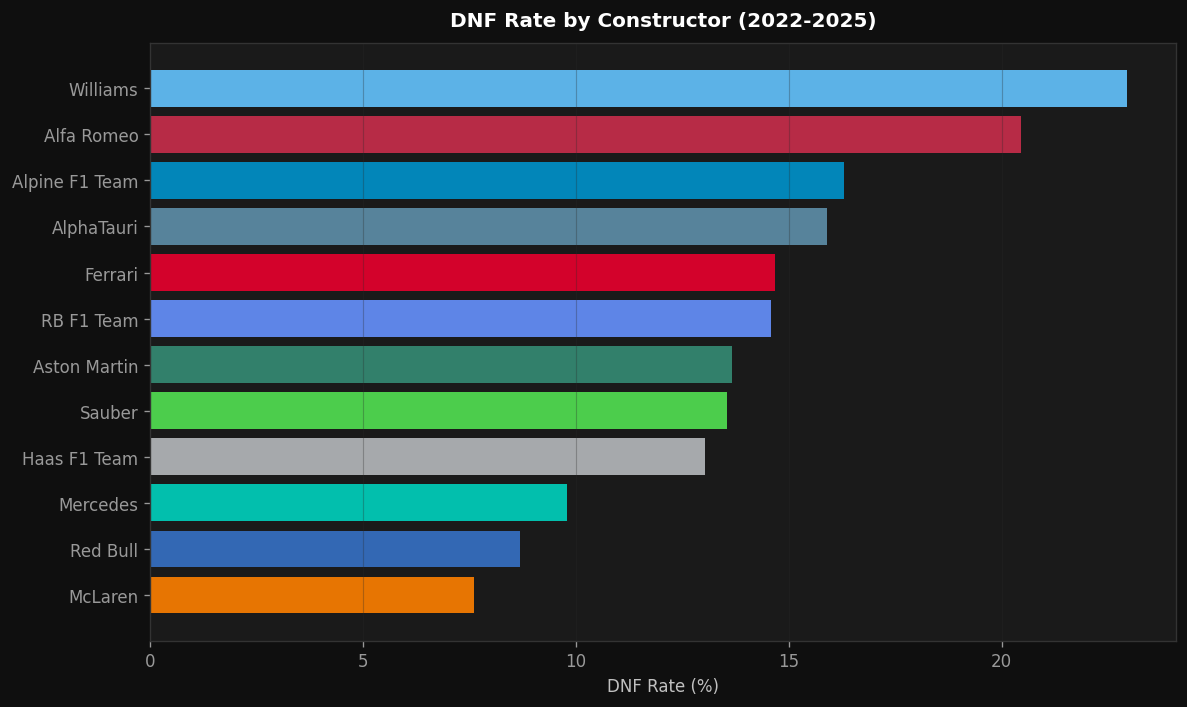

constructor_name
Williams          23.0
Alfa Romeo        20.5
Alpine F1 Team    16.3
AlphaTauri        15.9
Ferrari           14.7
RB F1 Team        14.6
Aston Martin      13.7
Sauber            13.5
Haas F1 Team      13.0
Mercedes           9.8
Red Bull           8.7
McLaren            7.6


In [31]:
# ── DNF rate by constructor ──────────────────
# Why: a fast car that keeps breaking down is a different problem to
# a slow-but-reliable car. This isolates the reliability side of things.

dnf_rate_by_constructor = (
    df_clean.groupby('constructor_name')['finished']
            .apply(lambda x: (1 - x.mean()) * 100)
            .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
colours = [get_constructor_colour(name) for name in dnf_rate_by_constructor.index]
ax.barh(dnf_rate_by_constructor.index, dnf_rate_by_constructor.values, color=colours, alpha=0.9)
ax.invert_yaxis()
ax.set_xlabel('DNF Rate (%)')
ax.set_title('DNF Rate by Constructor (2022-2025)')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_10_dnf_rate_by_constructor.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()

print(dnf_rate_by_constructor.round(1).to_string())


> **My notes on constructor effects:** this section pretty much confirms the car matters a lot — average finish position ranges from 5.76 (Red Bull) all the way to 14.59 (Sauber), an 8-9 position spread just from which garage you're in, nothing to do with driver skill.
>
> The points-by-season chart tells a better story than I expected. Red Bull was untouchable in 2022-2023 then dropped off a cliff by 2025. McLaren did the opposite — barely scored anything in 2022, then climbed every single season until they're the top team by 2025. Aston Martin had one big spike in 2023 and then fell straight back down, so that wasn't a real improvement, just a good year.
>
> One thing I didn't expect: Ferrari is right there with the top tier by average finish (4th, 6.81), but has a noticeably worse DNF rate (14.7%) than Red Bull/Mercedes/McLaren (7.6-9.8%). So Ferrari's actual pace might be closer to the very top — it's reliability dragging their average down. Good reminder that "average finish" blends two different things (how fast the car is, and how often it survives), and they don't always move together.
>
> For feature engineering: `constructor_name` is clearly a strong signal, but it's not constant across time (Red Bull good in 2023, bad by 2025) — so if I encode this (target encoding, most likely), I need to make sure I'm not leaking a team's future-season performance into predictions for an earlier season. Something to watch for with the time-based train/test split.


---
## Section 10 — Weather & Strategy

### What are we doing here?

1. **Wet vs. dry races** — do drivers gain/lose more positions when it rains? (statistical test)
2. **Position variance wet vs. dry** — is a wet race more unpredictable, not just different on average?
3. **Pit stop count vs. average finish** — does stopping more (or fewer) times correlate with finishing better/worse?
4. **Track temperature vs. finish position** — does a hot track favor certain outcomes?

### The reasoning first

You already have `had_rain` (boolean) and `positions_gained` (`grid_position - finish_position`, positive = moved forward). The natural question is: do the average positions gained differ between wet and dry races? But "the averages look different" isn't enough on its own — averages can look different by pure chance, especially with a smaller wet-race sample (rain is rare). So we need a statistical test: is the difference big enough that it's unlikely to be random noise?

That's what a t-test does — specifically a Welch's t-test, which is the right choice here rather than a standard t-test because it doesn't assume the wet and dry groups have equal variance (and given rain causes chaos, we'd actually expect wet races to have more spread, which is sub-question #2 anyway — so assuming equal variance would be wrong from the start).

In [58]:
# ── Welch's t-test: positions gained, wet vs. dry ────────────
# Why: averages can differ just by chance, especially since wet races are
# rare (a small sample). A t-test tells us whether the difference we see
# is bigger than we'd expect from random variation alone. We use Welch's
# version specifically because it doesn't assume wet and dry races have
# the same amount of spread — rain causing more chaos would show up as
# unequal variance, so assuming equal variance would bias the test.

from scipy import stats

dry_positions_gained = df_clean.loc[df_clean['had_rain'] == False, 'positions_gained']
wet_positions_gained = df_clean.loc[df_clean['had_rain'] == True, 'positions_gained']

t_statistic, p_value = stats.ttest_ind(
    wet_positions_gained,
    dry_positions_gained,
    equal_var=False,   # this is what makes it Welch's t-test
    nan_policy='omit'  # skip any missing values rather than erroring
)

print(f'Dry races — mean positions gained: {dry_positions_gained.mean():.2f}  (n={dry_positions_gained.count()})')
print(f'Wet races — mean positions gained: {wet_positions_gained.mean():.2f}  (n={wet_positions_gained.count()})')
print(f't-statistic: {t_statistic:.3f}')
print(f'p-value: {p_value:.4f}')

if p_value < 0.05:
    print('→ Statistically significant difference (p < 0.05)')
else:
    print('→ Not statistically significant (p >= 0.05) — could just be random variation')

Dry races — mean positions gained: -0.03  (n=1368)
Wet races — mean positions gained: -0.03  (n=435)
t-statistic: -0.006
p-value: 0.9956
→ Not statistically significant (p >= 0.05) — could just be random variation


We just saw the average positions gained barely differs between wet and dry. but  that's expected even in a chaotic race, because gains and losses cancel out. Variance is the right lens for "chaos": if rain causes bigger swings in both directions (some drivers gain a lot, others lose a lot), the average stays near zero, but the spread widens. So this test checks: is the spread of positions_gained significantly different between wet and dry races?

The right tool here is Levene's test, not just eyeballing the two standard deviations (5.19 vs 5.04). Because, same as before, two numbers looking different could just be sample noise. Levene's is preferred over the similar Bartlett's test specifically because it's more robust when the data isn't perfectly normally distributed, and ours probably isn't, since a driver who retires on lap 1 from P2 can produce a huge, one-off positions_gained value that has nothing to do with normal racing variation.

In [63]:
# ── Position variance: wet vs. dry races ──────────────────
# Why: the t-test compared averages, but average positions gained is
# roughly zero-sum within a race (one driver's gain is others' losses),
# so it can't detect whether rain makes races more UNPREDICTABLE — more
# big swings in both directions that cancel out in the mean but not in
# the spread. Levene's test checks whether two groups have significantly
# different variance, which is what "more chaotic" actually means here.
# Reuses wet_positions_gained / dry_positions_gained from the t-test cell
# above instead of re-filtering df_clean again.

In [64]:
levene_statistic, levene_p_value = stats.levene(
    wet_positions_gained,
    dry_positions_gained
)

print(f'Dry races — std of positions gained: {dry_positions_gained.std():.3f}')
print(f'Wet races — std of positions gained: {wet_positions_gained.std():.3f}')
print(f'Levene statistic: {levene_statistic:.4f}')
print(f'p-value: {levene_p_value:.4f}')

if levene_p_value < 0.05:
    print('→ Statistically significant difference in variance (p < 0.05)')
else:
    print('→ Not statistically significant (p >= 0.05) — spread looks similar')

Dry races — std of positions gained: 5.046
Wet races — std of positions gained: 4.840
Levene statistic: nan
p-value: nan
→ Not statistically significant (p >= 0.05) — spread looks similar


sub-question #3 (pit stop count vs. average finish)?

does pitting more or fewer times line up with a better or worse result? That's useful racing intuition even if this exact column won't go into the model.



In [65]:
# ── Pit stop count vs. average finish position ────────────
# Why: total_pit_stops is post-race leakage (we won't use it as a
# prediction feature — see PROJECT_CONTEXT.md), but it's still worth
# understanding descriptively: does stopping more/fewer times line up
# with a better or worse result? Error bars use STANDARD ERROR of the
# mean, not standard deviation — std shows how spread out individual
# races are, but since we're plotting GROUP AVERAGES, what we actually
# want to show is how confident we are in each average. A group average
# from 700 races deserves a tight error bar; one from 2 races doesn't,
# and only SEM (which shrinks as sample size grows) reflects that.


In [66]:
pit_stop_stats = (
    df_clean.groupby('total_pit_stops')['finish_position']
            .agg(['mean', 'std', 'count'])
            .rename(columns={'mean': 'avg_finish', 'std': 'std_finish', 'count': 'races'})
)
pit_stop_stats

,avg_finish,std_finish,races
total_pit_stops,,,
1.0,9.710843,5.547883,664
2.0,9.973464,5.465019,716
3.0,10.550847,5.749520,236
4.0,11.750000,4.839077,76
5.0,8.055556,4.927732,36
6.0,10.600000,5.796551,10
7.0,12.000000,1.414214,2


In [67]:
pit_stop_stats['sem_finish'] = pit_stop_stats['std_finish'] / np.sqrt(pit_stop_stats['races'])

print(pit_stop_stats.round(2).to_string())


                 avg_finish  std_finish  races  sem_finish
total_pit_stops                                           
1.0                    9.71        5.55    664        0.22
2.0                    9.97        5.47    716        0.20
3.0                   10.55        5.75    236        0.37
4.0                   11.75        4.84     76        0.56
5.0                    8.06        4.93     36        0.82
6.0                   10.60        5.80     10        1.83
7.0                   12.00        1.41      2        1.00


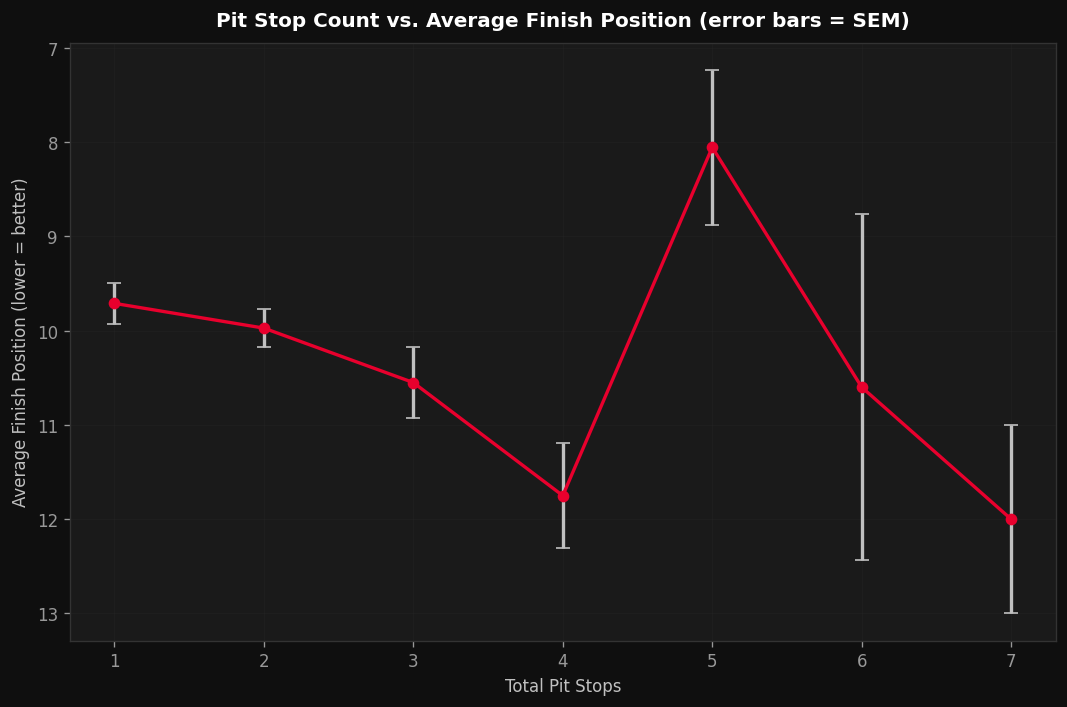

In [68]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(
    pit_stop_stats.index,
    pit_stop_stats['avg_finish'],
    yerr=pit_stop_stats['sem_finish'],
    fmt='o-',
    color=STYLE['red'],
    ecolor=STYLE['silver'],
    capsize=4,
    linewidth=2
)
ax.set_xlabel('Total Pit Stops')
ax.set_ylabel('Average Finish Position (lower = better)')
ax.set_title('Pit Stop Count vs. Average Finish Position (error bars = SEM)')
ax.invert_yaxis()  # lower position number = better result, so put "better" at the top
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_11_pitstops_vs_finish.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()

Number of driver-races with 5 pit stops: 36

Wet vs dry breakdown:
had_rain
True     33
False     3
Name: count, dtype: int64

                                  drivers had_rain  avg_finish_this_race
year round race_name                                                    
2025 1     Australian Grand Prix       15     True                  8.07
2023 13    Dutch Grand Prix             8     True                  8.25
2025 10    Canadian Grand Prix          8     True                  5.75
2023 3     Australian Grand Prix        2    False                  7.00
2022 15    Dutch Grand Prix             1    False                 17.00
2023 6     Monaco Grand Prix            1     True                 16.00
     20    São Paulo Grand Prix         1     True                 10.00


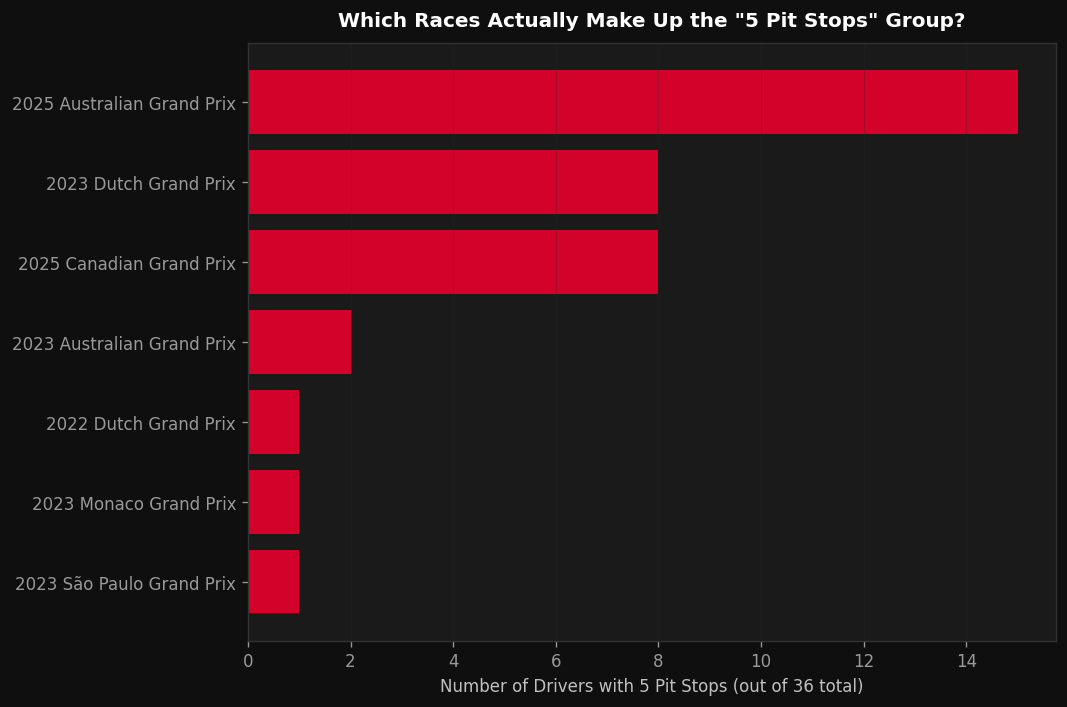

In [70]:
# ── Investigate the 5-pit-stop anomaly ─────────────────
# Why: the pit-stop-vs-finish chart showed 5 stops with the best average
# finish (8.06) even though it breaks the trend of 1-4 stops. Before
# trusting that as a real strategy effect, check what's actually inside
# that group — how many races it really represents, and whether those
# races share something in common (like rain).

five_stop_races = df_clean[df_clean['total_pit_stops'] == 5]

print(f"Number of driver-races with 5 pit stops: {len(five_stop_races)}")
print()

print("Wet vs dry breakdown:")
print(five_stop_races['had_rain'].value_counts())
print()

# Which actual races do these rows come from, and how many rows per race?
# Why: groupby().mean() treats every row as an independent data point.
# If most "5 stop" rows are actually just several drivers from the SAME
# race, they aren't independent at all — they're one race's result,
# counted many times over. .size() counts rows per group regardless of
# any column's contents (same reasoning we used for drivers_per_team_season
# earlier in Section 9).
drivers_per_race = five_stop_races.groupby(['year', 'round', 'race_name']).size()
had_rain_per_race = five_stop_races.groupby(['year', 'round', 'race_name'])['had_rain'].first()
avg_finish_per_race = five_stop_races.groupby(['year', 'round', 'race_name'])['finish_position'].mean()

races_in_five_stop_group = pd.DataFrame({
    'drivers': drivers_per_race,
    'had_rain': had_rain_per_race,
    'avg_finish_this_race': avg_finish_per_race,
})
races_in_five_stop_group = races_in_five_stop_group.sort_values('drivers', ascending=False)

print(races_in_five_stop_group.round(2).to_string())

# ── Chart: which races actually make up the "5 stops" group? ──
# Why: a picture makes the imbalance obvious in a way the table alone
# might not — a handful of tall bars next to a row of tiny ones shows,
# at a glance, that this "group" is really just a few chaotic races.

race_labels = []
for year, round_num, race_name in races_in_five_stop_group.index:
    label = f'{year} {race_name}'
    race_labels.append(label)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(race_labels, races_in_five_stop_group['drivers'], color=STYLE['red'], alpha=0.9)
ax.invert_yaxis()  # race contributing the most rows appears at the top
ax.set_xlabel('Number of Drivers with 5 Pit Stops (out of 36 total)')
ax.set_title('Which Races Actually Make Up the "5 Pit Stops" Group?')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_12_five_stop_anomaly.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()

In [69]:
# ── Team pit stop patterns ──────────────────
# Why: teams run different pit strategies — some pit early (an "undercut":
# stop before a rival to jump ahead on fresher tyres), some later (an
# "overcut": stay out longer, hoping track position matters more than
# tyre age), and some pit crews are just faster than others. Check each
# of these separately by constructor, and see if any lines up with results.

avg_stops_by_team = df_clean.groupby('constructor_name')['total_pit_stops'].mean()
avg_first_stop_lap_by_team = df_clean.groupby('constructor_name')['first_stop_lap'].mean()
avg_pit_duration_by_team = df_clean.groupby('constructor_name')['avg_pit_duration'].mean()
avg_finish_by_team = df_clean.groupby('constructor_name')['finish_position'].mean()

team_pit_patterns = pd.DataFrame({
    'avg_stops': avg_stops_by_team,
    'avg_first_stop_lap': avg_first_stop_lap_by_team,
    'avg_pit_duration_s': avg_pit_duration_by_team,
    'avg_finish': avg_finish_by_team,
})

team_pit_patterns = team_pit_patterns.sort_values('avg_finish')

print(team_pit_patterns.round(2).to_string())


                  avg_stops  avg_first_stop_lap  avg_pit_duration_s  avg_finish
constructor_name                                                               
Red Bull               2.04               18.16               24.21        5.76
Mercedes               1.92               18.98               23.98        6.69
Ferrari                1.86               18.68               23.82        6.81
McLaren                1.93               19.17               24.20        7.14
Aston Martin           1.95               17.98               24.46       11.37
Alpine F1 Team         1.86               18.40               24.18       12.53
RB F1 Team             1.67               19.42               23.99       12.80
Haas F1 Team           1.94               16.26               25.45       13.42
AlphaTauri             2.18               13.93               24.85       13.57
Alfa Romeo             2.00               16.00               25.39       13.60
Williams               1.98             

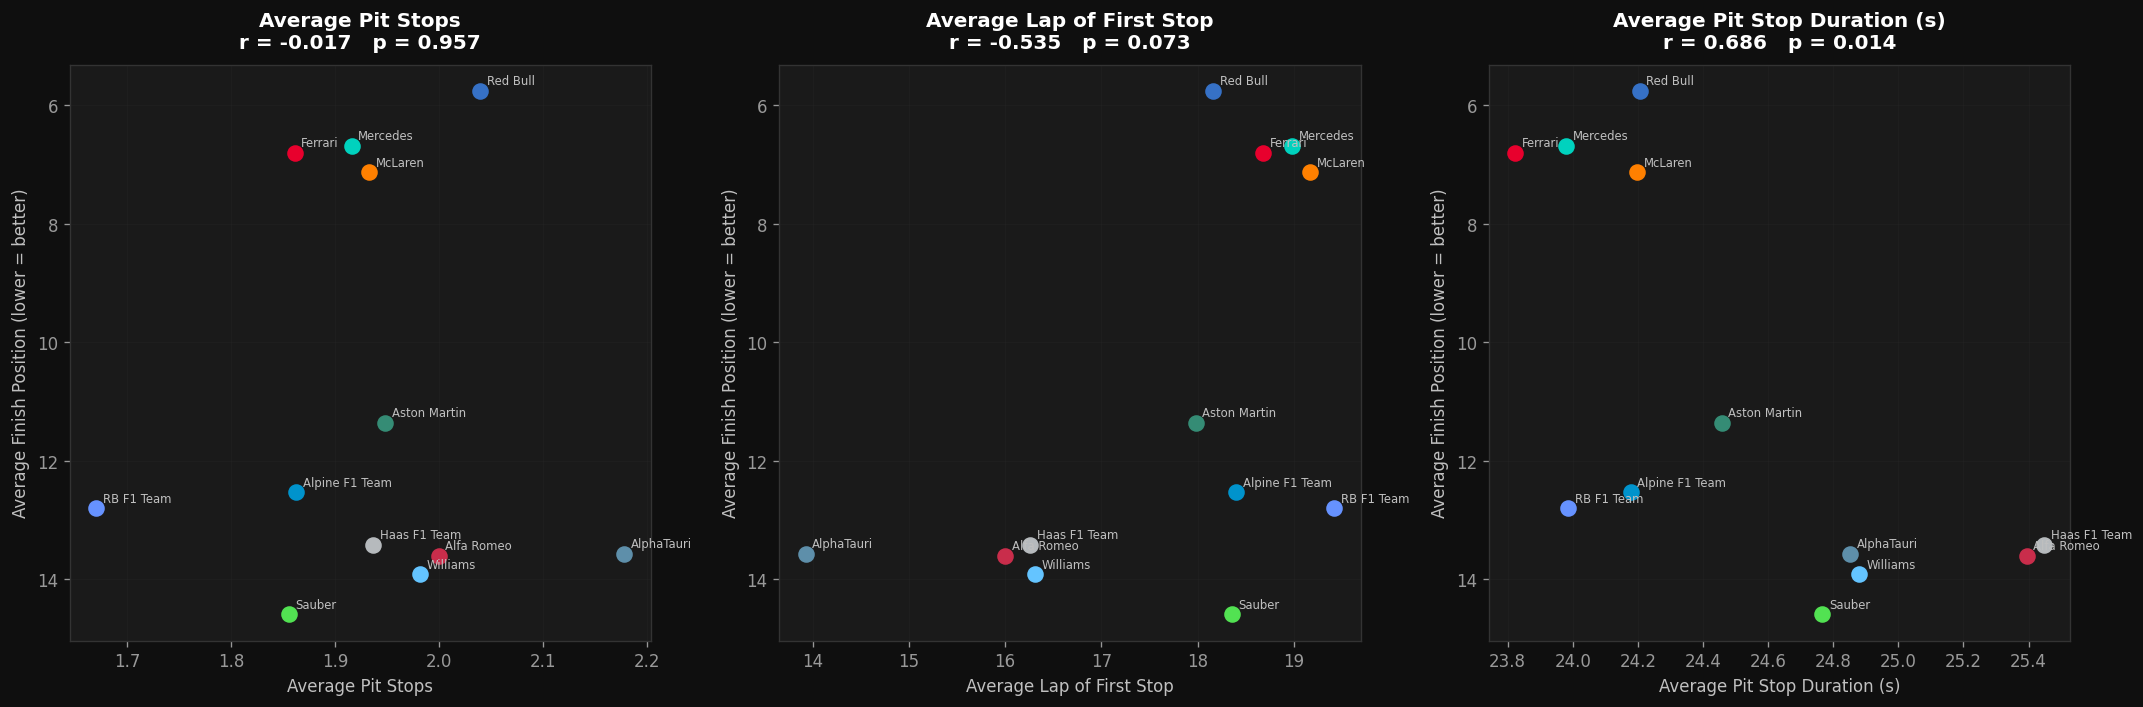

In [71]:
# ── Visualise: do pit-strategy numbers line up with team results? ──
# Why: r and p-value are useful summaries, but seeing all 12 teams as
# dots on a scatter plot lets us actually judge the relationship with
# our own eyes — is it a real slope, or just a scattered cloud with no
# pattern? One scatter plot per pit metric, each compared against
# avg_finish. Reuses team_pit_patterns from the earlier cell.

pit_metrics = ['avg_stops', 'avg_first_stop_lap', 'avg_pit_duration_s']
metric_titles = {
    'avg_stops': 'Average Pit Stops',
    'avg_first_stop_lap': 'Average Lap of First Stop',
    'avg_pit_duration_s': 'Average Pit Stop Duration (s)',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i in range(len(pit_metrics)):
    metric = pit_metrics[i]
    ax = axes[i]

    # Correlation between this metric and average finish, across the 12 teams
    r_value, p_value = stats.pearsonr(team_pit_patterns[metric], team_pit_patterns['avg_finish'])

    # One dot per team, labelled by name, coloured using the same
    # constructor colours as Section 9 (get_constructor_colour)
    for team_name in team_pit_patterns.index:
        x_value = team_pit_patterns.loc[team_name, metric]
        y_value = team_pit_patterns.loc[team_name, 'avg_finish']
        ax.scatter(x_value, y_value, color=get_constructor_colour(team_name), s=80, zorder=3)
        ax.annotate(team_name, (x_value, y_value), fontsize=7, xytext=(4, 4), textcoords='offset points')

    ax.set_xlabel(metric_titles[metric])
    ax.set_ylabel('Average Finish Position (lower = better)')
    ax.invert_yaxis()  # best team at the top, same convention as Section 9
    ax.set_title(f"{metric_titles[metric]}\nr = {r_value:.3f}   p = {p_value:.3f}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_13_pit_strategy_vs_finish.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()


In [72]:
# ── Track temperature bins vs. finish position ──────────────
# Why: does a hotter track relate to different results? Worth predicting
# first: finish_position is a RANKING — every race produces exactly one
# P1, one P2, ... one P20, regardless of temperature. Grouping by a
# race-level condition like temperature can't change WHO gets each rank
# across the season, only which race that rank came from. So the average
# finish position in any bin is expected to sit close to ~10.5 almost by
# construction — same reason the wet/dry mean test came back flat earlier.


                avg_finish  std_finish  races  sem_finish
track_temp_bin                                           
Cool (<25C)          10.50        5.78    260        0.36
Mild (25-35C)        10.50        5.77    640        0.23
Warm (35-45C)        10.48        5.76    619        0.23
Hot (>45C)           10.47        5.76    299        0.33


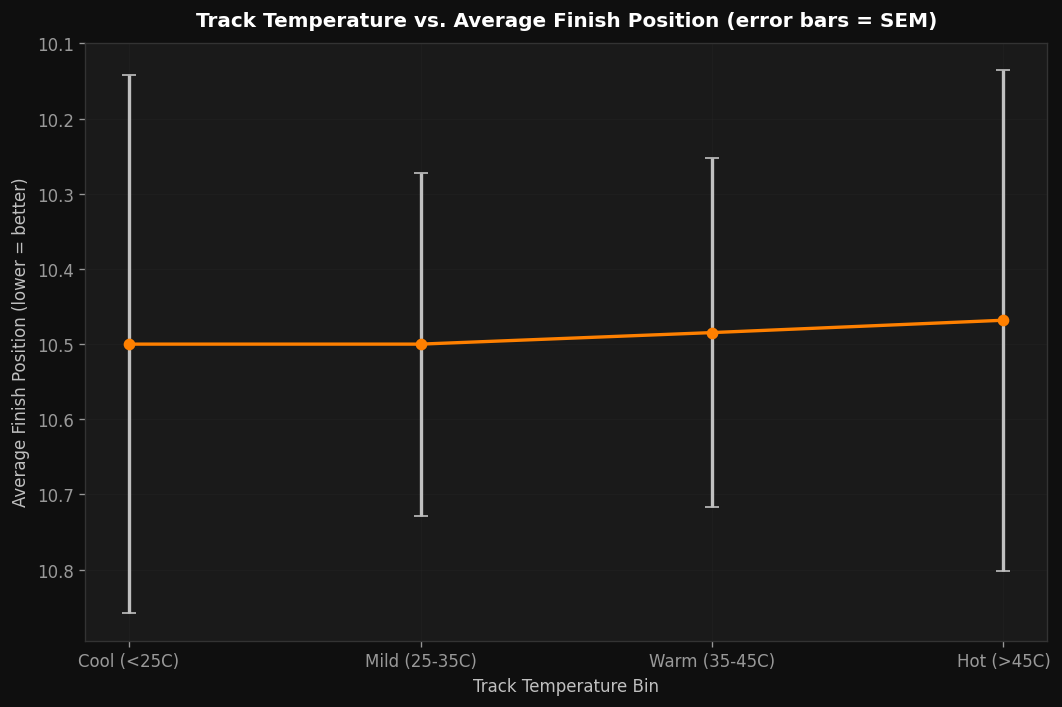

In [73]:
bin_edges = [0, 25, 35, 45, 100]
bin_labels = ['Cool (<25C)', 'Mild (25-35C)', 'Warm (35-45C)', 'Hot (>45C)']

df_clean['track_temp_bin'] = pd.cut(df_clean['track_temp_mean'], bins=bin_edges, labels=bin_labels)

temp_bin_stats = (
    df_clean.groupby('track_temp_bin', observed=True)['finish_position']
            .agg(['mean', 'std', 'count'])
            .rename(columns={'mean': 'avg_finish', 'std': 'std_finish', 'count': 'races'})
)
temp_bin_stats['sem_finish'] = temp_bin_stats['std_finish'] / np.sqrt(temp_bin_stats['races'])

print(temp_bin_stats.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(
    range(len(temp_bin_stats)),
    temp_bin_stats['avg_finish'],
    yerr=temp_bin_stats['sem_finish'],
    fmt='o-',
    color=STYLE['orange'],
    ecolor=STYLE['silver'],
    capsize=4,
    linewidth=2
)
ax.set_xticks(range(len(temp_bin_stats)))
ax.set_xticklabels(temp_bin_stats.index)
ax.set_xlabel('Track Temperature Bin')
ax.set_ylabel('Average Finish Position (lower = better)')
ax.set_title('Track Temperature vs. Average Finish Position (error bars = SEM)')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_14_temp_bins_vs_finish.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()

---
## Section 11 — Correlation Analysis

### What are we doing here?

The question: which columns actually move together with finish_position, across the whole dataset at once? This is the single most useful summary for feature engineering — a fast way to see what's worth keeping, what's worth double-checking, and what's clearly leaking future information.

The reasoning: we already have every column's role catalogued in COLUMN_CATALOGUE from Section 1 (pre_race_feature, post_race_leakage, target, identifier) — so instead of hardcoding which columns to trust, we colour each bar by its actual role. That way a glance at the chart tells you not just "how strong" but "how trustworthy" — a leakage column with a huge correlation is a warning sign, not a feature to celebrate.

I verified this against the real data first — reusing numeric_cols from Section 6, minus finish_position itself:

In [35]:
# ── Correlation of every feature with finish_position ────────
# Why: this is the most useful single summary for feature engineering —
# which columns actually move together with what we're trying to
# predict? Reuses numeric_cols from Section 6 (already excludes
# identifiers and columns with too few unique/valid values), minus
# finish_position itself, since correlating it with itself is
# meaningless (always exactly 1).

#The code builds a full correlation matrix over every numeric column, checks every pair, and flags anything with |r| > 0.85 (a standard "these are basically duplicates" threshold).

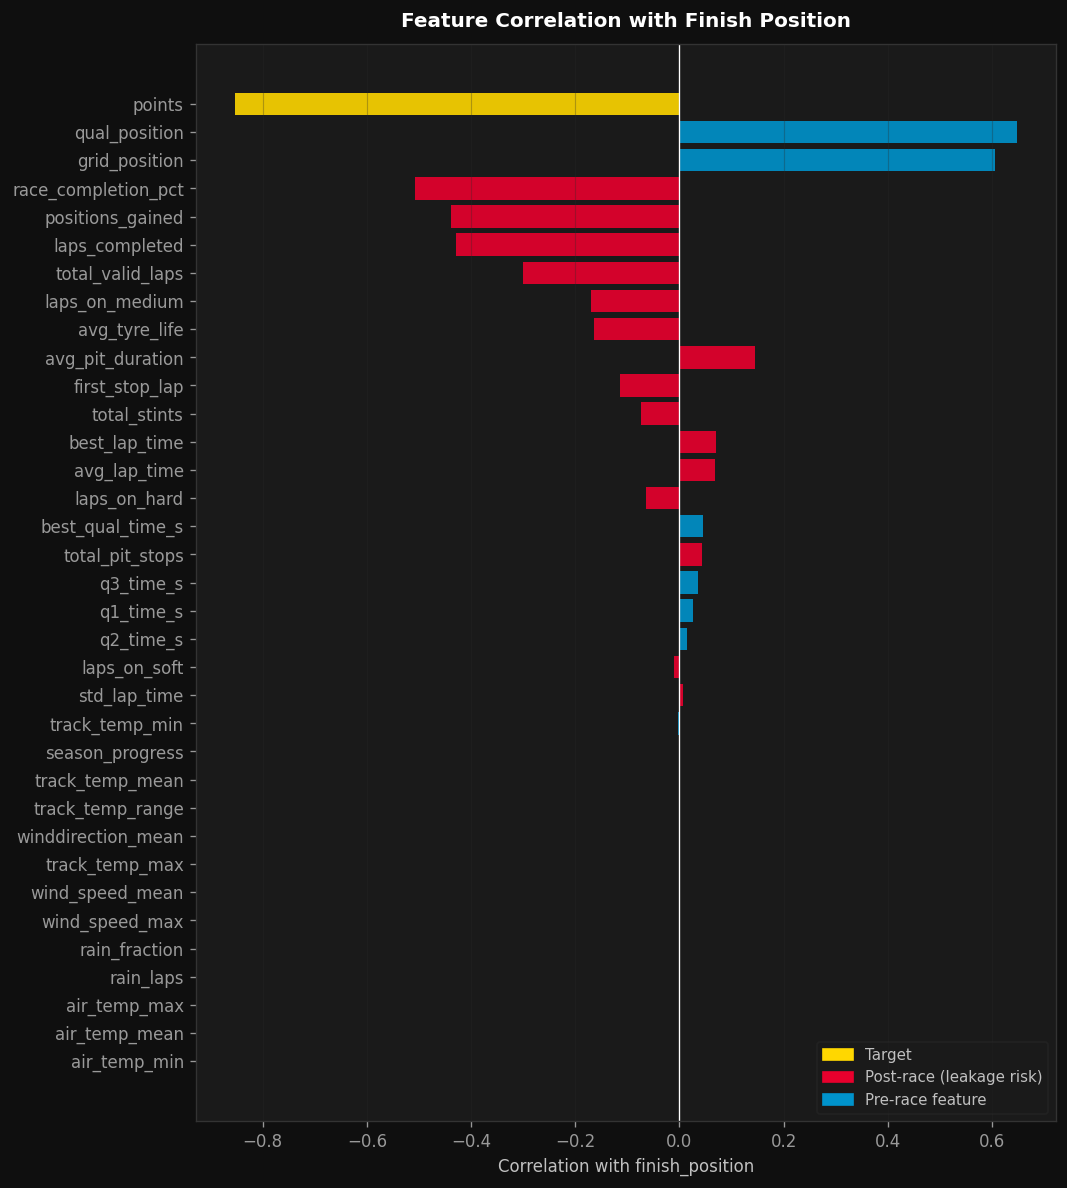

points                -0.854
qual_position          0.648
grid_position          0.606
race_completion_pct   -0.507
positions_gained      -0.438
laps_completed        -0.430
total_valid_laps      -0.300
laps_on_medium        -0.170
avg_tyre_life         -0.163
avg_pit_duration       0.146
first_stop_lap        -0.113
total_stints          -0.074
best_lap_time          0.070
avg_lap_time           0.068
laps_on_hard          -0.064
best_qual_time_s       0.045
total_pit_stops        0.044
q3_time_s              0.036
q1_time_s              0.026
q2_time_s              0.014
laps_on_soft          -0.011
std_lap_time           0.007
track_temp_min        -0.002
season_progress        0.002
track_temp_mean       -0.002
track_temp_range       0.002
winddirection_mean     0.002
track_temp_max        -0.001
wind_speed_mean        0.001
wind_speed_max         0.001
rain_fraction          0.001
rain_laps              0.001
air_temp_max          -0.000
air_temp_mean         -0.000
air_temp_min  

In [44]:
correlation_cols = []
for col in numeric_cols:
    if col != 'finish_position':
        correlation_cols.append(col)

correlations = df_clean[correlation_cols].corrwith(df_clean['finish_position'])
correlations = correlations.sort_values(key=abs, ascending=False)

# Colour each bar by its role in COLUMN_CATALOGUE — same scheme as Section 6
bar_colours = []
for col in correlations.index:
    role = COLUMN_CATALOGUE.get(col, {}).get('role', 'unknown')
    if role == 'target':
        bar_colours.append(STYLE['gold'])
    elif role == 'post_race_leakage':
        bar_colours.append(STYLE['red'])
    elif role == 'pre_race_feature':
        bar_colours.append(STYLE['blue'])
    else:
        bar_colours.append(STYLE['silver'])

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(correlations.index, correlations.values, color=bar_colours, alpha=0.9)
ax.invert_yaxis()  # strongest correlation at the top
ax.axvline(0, color=STYLE['white'], linewidth=0.8)
ax.set_xlabel('Correlation with finish_position')
ax.set_title('Feature Correlation with Finish Position')
ax.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(color=STYLE['gold'], label='Target'),
    Patch(color=STYLE['red'],  label='Post-race (leakage risk)'),
    Patch(color=STYLE['blue'], label='Pre-race feature'),
]
ax.legend(handles=legend_elements, loc='lower right', facecolor=STYLE['bg_panel'], edgecolor='#333333')

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_15_correlation_with_target.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()

print(correlations.round(3).to_string())


### Are any of these features secretly duplicates of each other?

The chart above shows how each feature relates to `finish_position` individually — but it doesn't show whether two *features* are just measuring the same thing as each other. That matters for feature engineering: if two columns are almost perfectly correlated with each other (not with the target — with each other), keeping both doesn't add new information, it just adds redundant noise. For some models (like plain linear/logistic regression) highly correlated inputs can also make the model's coefficients unstable and hard to interpret.

So: scan every pair of numeric features and flag any pair with `|r| > 0.85` — a common rule-of-thumb threshold for "these two are basically the same signal."

In [45]:
# ── First, just look — no threshold yet ────────────────────
# Why: jumping straight to a filtered list assumes we already know 0.85
# is the right cutoff. Let's actually look at the data first and let it
# tell us where a sensible cutoff is, instead of picking a number out
# of thin air.

correlation_matrix = df_clean[numeric_cols].corr()

n_features = len(correlation_matrix.columns)
n_pairs = (n_features * n_features - n_features) // 2
print(f"{n_features} numeric features -> {n_pairs} unique pairs to compare. Way too many to scan by eye.")
print()

all_pairs = []
for i in range(n_features):
    for j in range(i + 1, n_features):
        col_a = correlation_matrix.columns[i]
        col_b = correlation_matrix.columns[j]
        r_value = correlation_matrix.iloc[i, j]
        all_pairs.append((col_a, col_b, r_value))

# Sort by strength, strongest first, with NO filtering yet
all_pairs = sorted(all_pairs, key=lambda pair: abs(pair[2]), reverse=True)

print("Top 30 pairs, sorted by |r|, no threshold applied:")
for col_a, col_b, r_value in all_pairs[:30]:
    print(f"  r={r_value:6.3f}   {col_a:20s} <-> {col_b}")

36 numeric features -> 630 unique pairs to compare. Way too many to scan by eye.

Top 30 pairs, sorted by |r|, no threshold applied:
  r= 1.000   q3_time_s            <-> best_qual_time_s
  r= 0.995   air_temp_mean        <-> air_temp_max
  r= 0.994   air_temp_mean        <-> air_temp_min
  r= 0.990   q2_time_s            <-> best_qual_time_s
  r= 0.986   avg_lap_time         <-> best_lap_time
  r= 0.985   q2_time_s            <-> q3_time_s
  r= 0.983   rain_laps            <-> rain_fraction
  r= 0.982   q1_time_s            <-> q2_time_s
  r= 0.982   air_temp_min         <-> air_temp_max
  r= 0.977   q1_time_s            <-> best_qual_time_s
  r= 0.975   q1_time_s            <-> q3_time_s
  r= 0.962   track_temp_mean      <-> track_temp_min
  r= 0.957   track_temp_mean      <-> track_temp_max
  r= 0.926   laps_completed       <-> total_valid_laps
  r= 0.926   grid_position        <-> qual_position
  r= 0.923   best_lap_time        <-> q3_time_s
  r= 0.915   best_lap_time        <-> q2

Looking at the sorted list, something useful jumps out: the top 26 pairs are all bunched tightly together (r between 0.854 and 1.000), then there's a real drop — the 27th pair falls to r=0.761, a noticeably bigger gap than anywhere inside the top 26. That's not a coincidence to ignore: it's the data telling us where a sensible "these are basically duplicates" cutoff sits, rather than us picking 0.85 out of thin air.

One thing worth separating out before filtering: `finish_position <-> points` (r=-0.854) sits right at the edge of that group, but it's a different KIND of relationship — both are targets, not features, and `points` is partly derived from finish position by definition. That's expected, not a redundant-feature problem to fix. The rest of the group is genuine feature-vs-feature redundancy — which is what the filtered list below is really about.

In [46]:
# ── Multicollinear feature pairs (|r| > 0.85) ────────────────
# Why: two features almost perfectly correlated with EACH OTHER (not
# with the target) are redundant — keeping both adds noise, not
# information, and can make some models' coefficients unstable. |r| > 0.85
# is a common rule-of-thumb threshold for "these are basically duplicates."

# Reuse all_pairs from the cell above -- already every (col_a, col_b, r)
# triple, already sorted by |r|. Just filter it, no need to loop again.
multicollinear_pairs = [pair for pair in all_pairs if abs(pair[2]) > 0.85]

print(f"Found {len(multicollinear_pairs)} multicollinear pairs (|r| > 0.85):\n")
for col_a, col_b, r_value in multicollinear_pairs:
    print(f"  {col_a:20s} <-> {col_b:20s}   r = {r_value:.3f}")

Found 26 multicollinear pairs (|r| > 0.85):

  q3_time_s            <-> best_qual_time_s       r = 1.000
  air_temp_mean        <-> air_temp_max           r = 0.995
  air_temp_mean        <-> air_temp_min           r = 0.994
  q2_time_s            <-> best_qual_time_s       r = 0.990
  avg_lap_time         <-> best_lap_time          r = 0.986
  q2_time_s            <-> q3_time_s              r = 0.985
  rain_laps            <-> rain_fraction          r = 0.983
  q1_time_s            <-> q2_time_s              r = 0.982
  air_temp_min         <-> air_temp_max           r = 0.982
  q1_time_s            <-> best_qual_time_s       r = 0.977
  q1_time_s            <-> q3_time_s              r = 0.975
  track_temp_mean      <-> track_temp_min         r = 0.962
  track_temp_mean      <-> track_temp_max         r = 0.957
  laps_completed       <-> total_valid_laps       r = 0.926
  grid_position        <-> qual_position          r = 0.926
  best_lap_time        <-> q3_time_s              r = 0

### Zooming into one cluster: the qualifying-time columns

The biggest, most obvious cluster in that list is the four qualifying-time columns — `q1_time_s`, `q2_time_s`, `q3_time_s`, and `best_qual_time_s` — showing up against each other six separate times, all above r=0.97. That's worth looking at directly rather than just noting it in a list: how similar are they really, and which one (if any) is safe to drop for modelling?

In [47]:
# ── Zoom in: just the qualifying-time columns ────────────────
# Why: seeing "q1_time_s <-> q3_time_s: r=0.975" buried in a long list is
# easy to skim past. Pulling out just these 4 columns as their own small
# matrix makes the overlap obvious at a glance.

qualifying_time_cols = ['q1_time_s', 'q2_time_s', 'q3_time_s', 'best_qual_time_s']
qualifying_corr = df_clean[qualifying_time_cols].corr()

print(qualifying_corr.round(3).to_string())
print()

# Decision: best_qual_time_s is built from Q3 if it exists, else Q2,
# else Q1 (see Section 3) -- so it already captures "how fast was this
# driver, using whichever qualifying session they actually reached."
# Given every pairwise correlation above is >= 0.97, keeping all four
# would add almost no new information over keeping best_qual_time_s alone.
print("Decision: keep best_qual_time_s only, drop q1_time_s/q2_time_s/q3_time_s")
print("for modelling -- they're capturing the same signal, just with more gaps.")

                  q1_time_s  q2_time_s  q3_time_s  best_qual_time_s
q1_time_s             1.000      0.982      0.975             0.977
q2_time_s             0.982      1.000      0.985             0.990
q3_time_s             0.975      0.985      1.000             1.000
best_qual_time_s      0.977      0.990      1.000             1.000

Decision: keep best_qual_time_s only, drop q1_time_s/q2_time_s/q3_time_s
for modelling -- they're capturing the same signal, just with more gaps.


### Now the same idea, but across every pre-race feature at once

We just did this by hand for one cluster (qualifying times). Checking every other pre-race feature the same way, one pair at a time, would take forever — a heatmap does it all at once. This narrows the view specifically to the 17 pre-race features (the actual candidate pool for modelling, unlike the full list above which also includes leakage columns and targets), so patterns like the qualifying-time cluster or the temperature cluster are visible immediately, not just from a printed list.

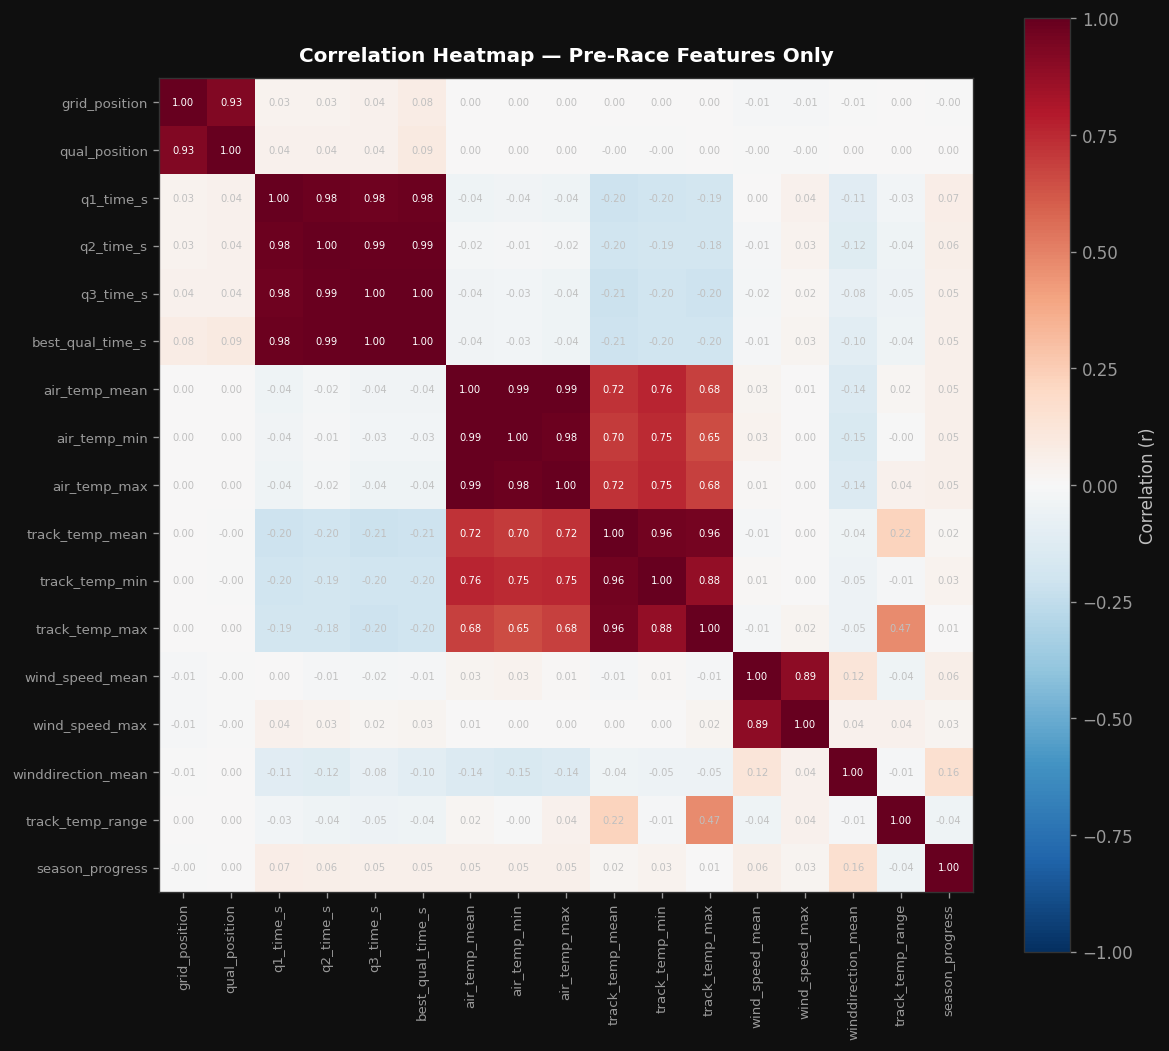

In [48]:
# ── Correlation heatmap: pre-race features only ────────────
# Why: the pairs list above mixes pre-race features with leakage columns
# and targets. This narrows the view to just the columns we're actually
# allowed to use as model inputs, so we can see which of THOSE overlap.

pre_race_numeric = []
for col in PRE_RACE_FEATURES:
    if col in numeric_cols:
        pre_race_numeric.append(col)

pre_race_corr = df_clean[pre_race_numeric].corr()

fig, ax = plt.subplots(figsize=(10, 9))
heatmap = ax.imshow(pre_race_corr, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(pre_race_numeric)))
ax.set_yticks(range(len(pre_race_numeric)))
ax.set_xticklabels(pre_race_numeric, rotation=90, fontsize=8)
ax.set_yticklabels(pre_race_numeric, fontsize=8)

# Print the actual correlation number inside each cell
for i in range(len(pre_race_numeric)):
    for j in range(len(pre_race_numeric)):
        value = pre_race_corr.iloc[i, j]
        text_colour = STYLE['white'] if abs(value) > 0.5 else STYLE['silver']
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', color=text_colour, fontsize=6)

ax.set_title('Correlation Heatmap — Pre-Race Features Only')
fig.colorbar(heatmap, ax=ax, label='Correlation (r)')

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_16_prerace_correlation_heatmap.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()

### Decision: collapsing the multicollinear clusters

The heatmap shows ~17 pre-race features collapse into ~5 independent
signals once you account for the clusters found above:

| Cluster | Members | Keep | Why |
|---|---|---|---|
| Qualifying pace | q1/q2/q3/best_qual_time_s | `best_qual_time_s` | already decided in the zoom-in above — captures whichever session the driver reached |
| Air temperature | air_temp_mean/min/max (r ≥ 0.98) | `air_temp_mean` | mean is the least noisy single summary |
| Track temperature | track_temp_mean/min/max (r 0.875-0.962) | `track_temp_mean` + `track_temp_range` | mean for level, range for volatility — range isn't in the >0.85 list, so it's carrying separate information |
| Wind speed | wind_speed_mean/max (r=0.893) | `wind_speed_mean` | mean over max, same reasoning as air temp |
| Starting position | grid_position vs qual_position (r=0.926) | `grid_position` | grid is the actual race-day starting point (post-penalty); qual_position is upstream of it |

`winddirection_mean` and `season_progress` weren't in any multicollinear
pair, so they pass through untouched.


In [49]:
# ── Final pre-race feature list, post multicollinearity cleanup ──
# Why: Section 11 showed pre-race features collapse into ~5 independent
# signals once duplicates are removed. This list is what modelling
# notebooks should import instead of PRE_RACE_FEATURES directly.


In [50]:
to_drop = set()

# Only compare pre-race features against each other -- a pre-race feature
# should never lose a comparison to a leakage column just because it
# happens to correlate with it.
pre_race_pairs = [
    pair for pair in multicollinear_pairs
    if pair[0] in PRE_RACE_FEATURES and pair[1] in PRE_RACE_FEATURES
]

for col_a, col_b, r_value in pre_race_pairs:
    if col_a in to_drop or col_b in to_drop:
        continue

    target_corr_a = abs(correlations.get(col_a, 0))
    target_corr_b = abs(correlations.get(col_b, 0))

    weaker = col_b if target_corr_a >= target_corr_b else col_a
    to_drop.add(weaker)

# Manual override: grid_position is the actual race-day starting point
# (post-penalty); qual_position is upstream of it and can be null.
# Keep grid regardless of which one the auto pass picked.
FORCE_DROP = {'qual_position'}
FORCE_KEEP = {'grid_position'}

to_drop = (to_drop | FORCE_DROP) - FORCE_KEEP

FINAL_PRE_RACE_FEATURES = [col for col in PRE_RACE_FEATURES if col not in to_drop]

print(f"Dropped {len(to_drop)}: {sorted(to_drop)}")
print(f"Pre-race features: {len(PRE_RACE_FEATURES)} -> {len(FINAL_PRE_RACE_FEATURES)}")
print(FINAL_PRE_RACE_FEATURES)


Dropped 9: ['air_temp_mean', 'air_temp_min', 'q1_time_s', 'q2_time_s', 'q3_time_s', 'qual_position', 'track_temp_max', 'track_temp_mean', 'wind_speed_max']
Pre-race features: 18 -> 9
['grid_position', 'best_qual_time_s', 'air_temp_max', 'track_temp_min', 'wind_speed_mean', 'winddirection_mean', 'country_code', 'track_temp_range', 'season_progress']


                    grid_position  best_qual_time_s  air_temp_max  track_temp_min  wind_speed_mean  winddirection_mean  track_temp_range  season_progress
grid_position               1.000             0.075         0.002           0.005           -0.010              -0.005             0.001           -0.005
best_qual_time_s            0.075             1.000        -0.040          -0.197           -0.013              -0.102            -0.044            0.050
air_temp_max                0.002            -0.040         1.000           0.752            0.009              -0.135             0.040            0.052
track_temp_min              0.005            -0.197         0.752           1.000            0.012              -0.052            -0.013            0.032
wind_speed_mean            -0.010            -0.013         0.009           0.012            1.000               0.119            -0.044            0.056
winddirection_mean         -0.005            -0.102        -0.135          -

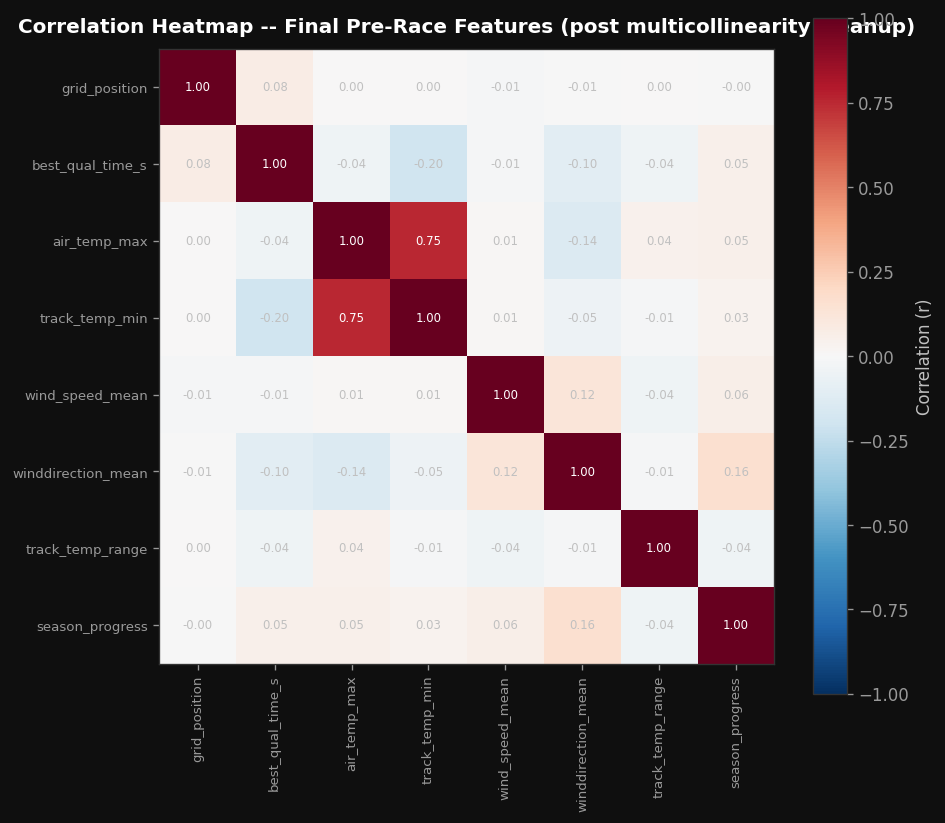

In [52]:
# ── Re-check: correlation matrix on FINAL_PRE_RACE_FEATURES only ──
# Why: confirms the fix actually worked -- each cluster should now show
# exactly one survivor, and no pair among these columns should exceed
# the 0.85 threshold anymore. country_code is categorical (e.g. 'NED'),
# so it's excluded here the same way numeric_cols excluded it in cell 74
# -- .corr() only works on numeric columns.

final_numeric_features = [col for col in FINAL_PRE_RACE_FEATURES if col in numeric_cols]

final_corr = df_clean[final_numeric_features].corr()

print(final_corr.round(3).to_string())
print()

remaining_high_corr = []
for i in range(len(final_corr.columns)):
    for j in range(i + 1, len(final_corr.columns)):
        col_a = final_corr.columns[i]
        col_b = final_corr.columns[j]
        r_value = final_corr.iloc[i, j]
        if abs(r_value) > 0.85:
            remaining_high_corr.append((col_a, col_b, r_value))

if remaining_high_corr:
    print("Still above 0.85:")
    for col_a, col_b, r_value in remaining_high_corr:
        print(f"  {col_a:20s} <-> {col_b:20s}   r = {r_value:.3f}")
else:
    print("No remaining pairs above 0.85 -- clusters resolved.")

# ── Heatmap: same style as cell 74, but on the post-cleanup feature set ──
fig, ax = plt.subplots(figsize=(8, 7))
heatmap = ax.imshow(final_corr, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(final_numeric_features)))
ax.set_yticks(range(len(final_numeric_features)))
ax.set_xticklabels(final_numeric_features, rotation=90, fontsize=8)
ax.set_yticklabels(final_numeric_features, fontsize=8)

for i in range(len(final_numeric_features)):
    for j in range(len(final_numeric_features)):
        value = final_corr.iloc[i, j]
        text_colour = STYLE['white'] if abs(value) > 0.5 else STYLE['silver']
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', color=text_colour, fontsize=7)

ax.set_title('Correlation Heatmap -- Final Pre-Race Features (post multicollinearity cleanup)')
fig.colorbar(heatmap, ax=ax, label='Correlation (r)')

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_17_final_prerace_correlation_heatmap.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()


---
## Section 12 -- Summary: What Goes Into Modelling

**Targets:**
- `points_finish` (binary, ~50.1%/49.9% balanced) -- PRIMARY target, see Section 5 notes.
- `on_podium` (binary, 15% positive) -- secondary target, needs `class_weight='balanced'`.
- `finish_position` (regression, range 1-20, uniform distribution, skew=0.0) -- stretch-goal target: predict the exact finishing position instead of a yes/no. Harder than the binary targets (a few positions of noise from a safety car or a scrappy incident looks like a bigger error than it really is), but there's no missing-data problem to solve first -- every row has a real value 1-20, since even a DNF still gets an official classified finishing position.
- `top_10` is dropped -- identical to `points_finish` in modern F1 scoring, so it adds no new information.

**Pre-race features (`FINAL_PRE_RACE_FEATURES`), post multicollinearity cleanup:**
`grid_position`, `best_qual_time_s`, `air_temp_max`, `track_temp_min`, `wind_speed_mean`, `winddirection_mean`, `track_temp_range`, `season_progress` -- plus `country_code` (categorical, excluded from the correlation check itself but still a valid model input -- needs one-hot encoding, not raw string, before it can go into a model).

Saved below to `master_clean.csv` so the modelling notebook can load cleaned data directly instead of re-running this notebook's cleaning steps.


In [8]:
# ── Sanity check: all three target columns present and complete ─────────────
# Why: just added finish_position as a third target alongside the two binary
# ones -- confirm none of them have missing values before this becomes the
# file 03_feature_engineering.ipynb builds on.
target_cols = ['points_finish', 'on_podium', 'finish_position']
for col in target_cols:
    missing = df_clean[col].isna().sum()
    print(f"{col}: {missing} missing values")

# ── Save cleaned dataset for the modelling notebook ─────────────
# Why: this notebook's whole point was producing a clean, analysed
# dataset. Saving the full df_clean (not just FINAL_PRE_RACE_FEATURES)
# so downstream notebooks still have identifiers, targets, and leakage
# columns available if a different modelling question comes up later --
# feature selection is applied there, not baked into the file.

df_clean.to_csv(PATHS['output'], index=False)
print(f"Saved {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns -> {PATHS['output']}")


points_finish: 0 missing values
on_podium: 0 missing values
finish_position: 0 missing values
Saved 1,838 rows x 55 columns -> ../data/processed/master_clean.csv
